In [1]:
import os
import sys
from src import Single_view_model, Single_view_AJIVE_heads
from src import View_Cancer_Dataloader
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics import f1_score, balanced_accuracy_score, accuracy_score

from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from matplotlib.patches import Rectangle





import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ast
sys.path.insert(0, os.path.abspath("python_packages"))
from python_packages import *
from src import *
from src.py_divas import PyDIVAS
import tqdm 
import pickle



In [2]:
dataloader = View_Cancer_Dataloader(
    root_folder='/Users/jazav7774/Data/Mammo/',
    annotation_csv="modified_breast-level_annotations.csv",
    imagefolder_path="images_png_396",
    image_format="png",
    norm_kind="dataset_zscore",
    batch_size=32,  
    num_workers=1,
    task=1,
    use_train_sampler=False, 
)
model_cancer = Single_view_model.load_from_checkpoint('artifacts/model-ln6ychcp:v0/model.ckpt')
model_density = Single_view_model.load_from_checkpoint('artifacts/model-vjzmam1e:v0/model.ckpt')

In [3]:
annotations = pd.read_csv('/Users/jazav7774/Data/Mammo/vindr_detection_v1_folds.csv', low_memory=False)
annot_test = annotations[
    (annotations['image_id'].isin(dataloader.test_dataset.image_ids))
    & (annotations['finding_categories'] != "['No Finding']")
].copy()  # Add .copy() to avoid SettingWithCopyWarning
# Parse the string representation of lists into actual Python lists
annot_test['finding_categories_list'] = annot_test['finding_categories'].apply(ast.literal_eval)

# Now explode the dataframe so each finding category gets its own row
annot_test = annot_test.explode('finding_categories_list').reset_index(drop=True)

# Rename the column to reflect it now contains single categories
annot_test = annot_test.rename(columns={'finding_categories_list': 'finding_category'})
annot_test


,patient_id,series_id,image_id,laterality,view,height,width,breast_birads,breast_density,finding_categories,...,Global_Asymmetry,Mass,Nipple_Retraction,No_Finding,Skin_Retraction,Skin_Thickening,Suspicious_Calcification,Suspicious_Lymph_Node,density,finding_category
0,5683854eafabc34f6d854000d2ac6c2d,4ac33111294b83d43537cb8604b0808c,2f944efb1cb9579442df2d7fe6a579b7,L,CC,3518,2800,BI-RADS 3,DENSITY C,['Mass'],...,0,1,0,0,0,0,0,0,2,Mass
1,5683854eafabc34f6d854000d2ac6c2d,4ac33111294b83d43537cb8604b0808c,7385e8cf7b29764525c81de4aa1aebe4,L,MLO,3518,2800,BI-RADS 3,DENSITY C,['Mass'],...,0,1,0,0,0,0,0,0,2,Mass
2,917a4de3b1f921f1c9fa98b7a61d749d,22bada39b619f79a660b3a06eb6ff5a9,4dd8faf113a9421e03a6e2bcd4238da2,L,CC,3518,2800,BI-RADS 3,DENSITY C,['Mass'],...,0,1,0,0,0,0,0,0,2,Mass
3,917a4de3b1f921f1c9fa98b7a61d749d,22bada39b619f79a660b3a06eb6ff5a9,19056b152c5d2ed98f66de006fa45a6c,L,MLO,3518,2800,BI-RADS 3,DENSITY C,['Mass'],...,0,1,0,0,0,0,0,0,2,Mass
4,31fa226bc9f87e0a2cb2de6dddbc2270,98ca3b2d3a802a417d2942bc5f0fc036,625aa350502a7038cfe5f9ca5f1a65f4,L,MLO,3518,2800,BI-RADS 4,DENSITY C,['Mass'],...,0,1,0,0,0,0,0,0,2,Mass
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
483,b8acac150be7f949f78dc631a3851f8b,f351166fe105bea6f090e38f41bc844c,dbe631b24f8759c7f7022513582c39ba,R,CC,3580,2609,BI-RADS 4,DENSITY C,['Mass'],...,0,1,0,0,0,0,0,0,2,Mass
484,b8acac150be7f949f78dc631a3851f8b,f351166fe105bea6f090e38f41bc844c,bdf1539e07e60cfcb5e7833f5b63fa86,R,MLO,3580,2706,BI-RADS 4,DENSITY C,['Suspicious Lymph Node'],...,0,0,0,0,0,0,0,1,2,Suspicious Lymph Node
485,b8acac150be7f949f78dc631a3851f8b,f351166fe105bea6f090e38f41bc844c,bdf1539e07e60cfcb5e7833f5b63fa86,R,MLO,3580,2706,BI-RADS 4,DENSITY C,['Mass'],...,0,1,0,0,0,0,0,0,2,Mass
486,b8acac150be7f949f78dc631a3851f8b,f351166fe105bea6f090e38f41bc844c,bdf1539e07e60cfcb5e7833f5b63fa86,R,MLO,3580,2706,BI-RADS 4,DENSITY C,['Mass'],...,0,1,0,0,0,0,0,0,2,Mass


___
# Performing AJIVE

In [4]:
def create_comprehensive_tsne_comparison(feature_sets, labels, split_to_plot = 'train'):
    """
    Create comprehensive t-SNE comparison across different feature representations
    """    
    # Set up colors
    unique_labels = np.unique(labels)
    colors = plt.cm.Set1(np.linspace(0, 1, len(unique_labels)))
    n_classes = len(unique_labels)
    if n_classes == 5:
        class_names = {0: 'BI-RADS 1', 1: 'BI-RADS 2', 2: 'BI-RADS 3', 3: 'BI-RADS 4', 4: 'BI-RADS 5'}
    elif n_classes == 3:
        class_names = {0: 'Healthy', 1: 'Benign', 2: 'Malignant'}
    elif n_classes == 2:
        class_names = {0: 'No revisit', 1: 'Revisit'}
    
    # Calculate optimal subplot layout
    n_features = len(feature_sets)
    n_cols = 3  # Fixed 3 columns for better layout
    n_rows = int(np.ceil(n_features / n_cols))
    
    # Create subplots with proper layout
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
    
    # Flatten axes array for easy indexing (handles both 1D and 2D cases)
    if n_rows == 1:
        axes = axes if n_cols > 1 else [axes]  # Handle single row case
    else:
        axes = axes.flatten()  # Flatten 2D array to 1D
    
    for idx, (feature_name, features_train, features_val, features_test) in enumerate(feature_sets):
        print(f"Computing t-SNE for {feature_name}...")
        if split_to_plot == 'train':
            features = features_train
        elif split_to_plot == 'val':
            features = features_val
        elif split_to_plot == 'test':
            features = features_test
        else:
            raise ValueError("split_to_plot must be 'train', 'val', or 'test'")
        
        # Compute t-SNE
        tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
        features_tsne = tsne.fit_transform(features)
        
        # Plot on the correct axis
        ax = axes[idx]
        for i, label in enumerate(unique_labels):
            mask = labels == label
            ax.scatter(features_tsne[mask, 0], features_tsne[mask, 1], 
                      c=[colors[i]], label=f'{class_names.get(label, f"Class {label}")}',
                      alpha=0.7, s=15)
        
        ax.set_title(f't-SNE: {feature_name}\n({features.shape[1]} dimensions)', 
                    fontsize=12, fontweight='bold')
        ax.set_xlabel('t-SNE Component 1')
        ax.set_ylabel('t-SNE Component 2')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    # Hide any unused subplots
    for idx in range(n_features, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()   

def evaluate_svm_classifier(X_train, y_train, X_val, y_val, X_test, y_test, feature_name):
    """
    Train and evaluate an RBF SVM classifier with comprehensive metrics
    """
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    # Train RBF SVM
    svm_classifier = SVC(kernel='rbf', probability=True, random_state=42)
    #svm_classifier = SVC(kernel='linear', probability=True, random_state=42)
    svm_classifier.fit(X_train_scaled, y_train)
    
    # Make predictions
    test_pred = svm_classifier.predict(X_test_scaled)
    
    # Calculate comprehensive metrics
    test_acc_macro = balanced_accuracy_score(y_test, test_pred)  # Overall accuracy
    test_f1_macro = f1_score(y_test, test_pred, average='macro')
    test_f1_weighted = f1_score(y_test, test_pred, average='weighted')
    
    # Confusion matrix
    cm = confusion_matrix(y_test, test_pred)
    
    
    results = {
        'feature_name': feature_name,
        'feature_dims': X_train.shape[1],
        'test_acc_macro': test_acc_macro,
        'test_f1_macro': test_f1_macro,
        'test_f1_weighted': test_f1_weighted,
        'confusion_matrix': cm,
        'test_predictions': test_pred,
        'test_labels': y_test
    }
    
    return results, svm_classifier
    
def compare_feature_transformations_svm_clean(feature_sets, label_sets, verbose = True):
    """
    Clean version with execution tracking to prevent duplicate display
    """
    
    # Store results
    all_results = []
    
    if verbose:
        print("Comparing Feature Transformations with RBF SVM...")
        print("=" * 70)
    
    for i, (feature_name, X_train, X_val, X_test) in enumerate(feature_sets):
        if verbose:
            print(f"\n[{i+1}/{len(feature_sets)}] 🔍 {feature_name}")
            print(f"Dimensions: {X_train.shape[1]}")
            print("-" * 50)
        
        try:
            results, trained_svm = evaluate_svm_classifier(
                X_train, label_sets[0],
                X_val, label_sets[1],
                X_test, label_sets[2],
                feature_name
            )
            all_results.append(results)
            
            if verbose:
                print(f" Accuracy: {results['test_acc_macro']:.4f} | F1: {results['test_f1_macro']:.4f}")
            
        except Exception as e:
            print(f" ERROR: {str(e)}")
    
    if verbose:
        print(f"\n Execution completed: {len(all_results)} evaluations")
    return all_results

def plot_confusion_matrices_comparison(all_results):
    """
    Create a comprehensive confusion matrix comparison plot
    """
    n_methods = len(all_results)
    
    # Create figure with subplots
    fig, axes = plt.subplots(int(np.ceil(n_methods / 3)), 3, figsize=(18, 12))
    axes = axes.flatten()
    
    # Get unique class labels
    all_labels = set()
    for result in all_results:
        all_labels.update(result['test_labels'])
        all_labels.update(result['test_predictions'])
    class_labels = sorted(list(all_labels))
    
    for idx, result in enumerate(all_results):
        ax = axes[idx]
        
        # Plot confusion matrix
        cm = result['confusion_matrix']
        im = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                        xticklabels=class_labels, yticklabels=class_labels)
        
        # Add title with metrics
        title = f"{result['feature_name']}\n"
        title += f"Macro Acc: {result['test_acc_macro']:.3f}, "
        title += f"Macro F1: {result['test_f1_macro']:.3f}\n"
        title += f"Dims: {result['feature_dims']}"
        
        ax.set_title(title, fontsize=11, pad=20)
        ax.set_xlabel('Predicted Label')
        ax.set_ylabel('True Label')
    
    # Remove empty subplots if any
    for idx in range(n_methods, len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()
    
    return fig
        
def get_featurized_data(dataloader, model, model1):
    """
    Get the full featurized dataset from a dataloader.
    """
    model.to('mps')
    model.eval()
    model1.to('mps')
    model1.eval()
    with torch.no_grad():
        all_in_features = []
        all_in_features1 = []
        logits = []
        logits1 = []

        all_labels = []
        all_labels1 = []

        for batch in tqdm.tqdm(dataloader, desc="Featurizing dataset"):
            x, y1, y2 = batch
            #y = y1 if model.task == 1 else y2
            x = x.to('mps')
            all_labels.append(y1)
            all_labels1.append(y2)
            
            x0 = model.get_resnet_outputs(x)
            x1 = model1.get_resnet_outputs(x)

            all_in_features.append(x0)
            all_in_features1.append(x1)
            
            logits.append(model.fc(model.resnet.fc(x0)))
            logits1.append(model1.fc(model1.resnet.fc(x1)))
            
        all_in_features = torch.cat(all_in_features, dim=0)
        all_in_features1 = torch.cat(all_in_features1, dim=0)
        all_labels = torch.cat(all_labels, dim=0)
        all_labels1 = torch.cat(all_labels1, dim=0)
        logits = torch.cat(logits, dim=0)
        logits1 = torch.cat(logits1, dim=0)

    return all_in_features, all_labels, logits, all_in_features1, all_labels1, logits1    
    
def process_and_save_all_splits(breast_loader, model, model_dens, save_dir='saved_features'):
    """
    Process train, testidation, and test dataloaders and save features and labels.
    """
    os.makedirs(save_dir, exist_ok=True)
    
    splits = {
        'train': breast_loader.train_dataloader(),
        'val': breast_loader.val_dataloader(),
        'test': breast_loader.test_dataloader()
    }
    
    for split_name, dataloader in splits.items():
        print(f"Processing {split_name} split...")
        
        cancer_features, cancer_labels, cancer_logits, dens_features, dens_labels, dens_logits = get_featurized_data(
            dataloader, model, model_dens
        )
        
        # Move to CPU before saving
        cancer_features = cancer_features.cpu()
        cancer_labels = cancer_labels.cpu()
        cancer_logits = cancer_logits.cpu()
        dens_features = dens_features.cpu()
        dens_labels = dens_labels.cpu()
        dens_logits = dens_logits.cpu()
        
        # Also save as dictionary for convenience
        torch.save({
            'cancer_features': cancer_features,
            'cancer_labels': cancer_labels,
            'cancer_logits': cancer_logits,
            'dens_features': dens_features,
            'dens_labels': dens_labels,
            'dens_logits': dens_logits
        }, f'{save_dir}/all_data_{split_name}.pt')
        
        print(f"Saved {split_name} split with shapes:")
        print(f"  Cancer features: {cancer_features.shape}")
        print(f"  Cancer labels: {cancer_labels.shape}")
        print(f"  Cancer logits: {cancer_logits.shape}")
        print(f"  Density features: {dens_features.shape}")
        print(f"  Density labels: {dens_labels.shape}")
        print(f"  Density logits: {dens_logits.shape}")
        print()

In [5]:
if 1:
    #process_and_save_all_splits(dataloader, model_cancer, model_density, save_dir='saved_features/One_View_Canc_vs_Dens/')
    train_data = torch.load('saved_features/One_View_Canc_vs_Dens/all_data_train.pt')
    train_cancer_features = train_data['cancer_features'].numpy()
    train_cancer_labels = train_data['cancer_labels'].numpy()
    train_cancer_logits = train_data['cancer_logits'].numpy()
    train_dens_features = train_data['dens_features'].numpy()
    train_dens_labels = train_data['dens_labels'].numpy()
    train_dens_logits = train_data['dens_logits'].numpy()

    val_data = torch.load('saved_features/One_View_Canc_vs_Dens/all_data_val.pt')
    val_cancer_features = val_data['cancer_features'].numpy()
    val_cancer_labels = val_data['cancer_labels'].numpy()
    val_cancer_logits = val_data['cancer_logits'].numpy()
    val_dens_features = val_data['dens_features'].numpy()
    val_dens_labels = val_data['dens_labels'].numpy()
    val_dens_logits = val_data['dens_logits'].numpy()

    test_data = torch.load('saved_features/One_View_Canc_vs_Dens/all_data_test.pt')
    test_cancer_features = test_data['cancer_features'].numpy()
    test_cancer_labels = test_data['cancer_labels'].numpy()
    test_cancer_logits = test_data['cancer_logits'].numpy()
    test_dens_features = test_data['dens_features'].numpy()
    test_dens_labels = test_data['dens_labels'].numpy()
    test_dens_logits = test_data['dens_logits'].numpy()

    label_sets = (train_cancer_labels, val_cancer_labels, test_cancer_labels)
    dens_label_sets = (train_dens_labels, val_dens_labels, test_dens_labels)

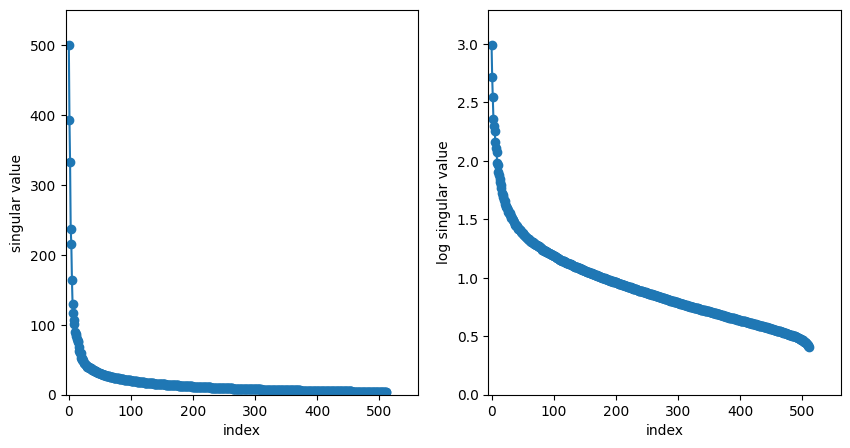

In [6]:
plt.figure(figsize=[10, 5])
plt.subplot(1, 2, 1)
PCA().fit(train_cancer_features).plot_scree(log = False)
plt.subplot(1, 2, 2)
PCA().fit(train_dens_features).plot_scree(log = True)

In [7]:
train_cancer_mask_correct = train_cancer_labels == np.argmax(train_cancer_logits, axis=1)

aj_train_correct = AJIVE(init_signal_ranks=(15,15), n_jobs=4, center=True)
aj_train_correct.fit([train_cancer_features[train_cancer_mask_correct], train_dens_features[train_cancer_mask_correct]])
aj_train_correct.summary()

'AJIVE, joint rank: 2, view 0 indiv rank: 13, view 1 indiv rank: 13'

In [8]:
temp_mask = np.isin(train_cancer_labels, [3,4])
train_cancer_mask_birads45_correct = (train_cancer_mask_correct & temp_mask)

aj_train_correct_BI45 = AJIVE(init_signal_ranks=(15,15), n_jobs=1, center=True)
aj_train_correct_BI45.fit([train_cancer_features[train_cancer_mask_birads45_correct], train_dens_features[train_cancer_mask_birads45_correct]])
aj_train_correct_BI45.summary()

'AJIVE, joint rank: 2, view 0 indiv rank: 13, view 1 indiv rank: 13'

In [9]:
aj = AJIVE(init_signal_ranks=[15,15], n_jobs=1, center=True)
aj.fit([train_cancer_features, train_dens_features])
aj.summary()


'AJIVE, joint rank: 3, view 0 indiv rank: 12, view 1 indiv rank: 12'

In [10]:
def get_ajive_projections(aj, train_cancer_features, val_cancer_features, test_cancer_features, train_dens_features, val_dens_features, test_dens_features):
    train_cancer_joint = aj.view_specific_[0].joint_.transform(train_cancer_features)
    val_cancer_joint = aj.view_specific_[0].joint_.transform(val_cancer_features)
    test_cancer_joint = aj.view_specific_[0].joint_.transform(test_cancer_features)

    train_individual_cancer = aj.view_specific_[0].individual_.transform(train_cancer_features)
    val_individual_cancer = aj.view_specific_[0].individual_.transform(val_cancer_features)
    test_individual_cancer = aj.view_specific_[0].individual_.transform(test_cancer_features)

    train_cancer_both = np.hstack([train_cancer_joint, train_individual_cancer])
    val_cancer_both = np.hstack([val_cancer_joint, val_individual_cancer])
    test_cancer_both = np.hstack([test_cancer_joint, test_individual_cancer])

    train_density_joint = aj.view_specific_[1].joint_.transform(train_dens_features)
    val_density_joint = aj.view_specific_[1].joint_.transform(val_dens_features)
    test_density_joint = aj.view_specific_[1].joint_.transform(test_dens_features)

    train_density_individual = aj.view_specific_[1].individual_.transform(train_dens_features)
    val_density_individual = aj.view_specific_[1].individual_.transform(val_dens_features)
    test_density_individual = aj.view_specific_[1].individual_.transform(test_dens_features)

    train_density_both = np.hstack([train_density_joint, train_density_individual])
    val_density_both = np.hstack([val_density_joint, val_density_individual])
    test_density_both = np.hstack([test_density_joint, test_density_individual])

    train_all_ajive = np.hstack([train_cancer_both, train_density_both])
    val_all_ajive = np.hstack([val_cancer_both, val_density_both])
    test_all_ajive = np.hstack([test_cancer_both, test_density_both])

    feature_sets = [
        #['Original cancer features', train_cancer_features, val_cancer_features, test_cancer_features],
        #['Original density features', train_dens_features, val_dens_features, test_dens_features],
        ['Cancer joint components', train_cancer_joint, val_cancer_joint, test_cancer_joint],
        ['Cancer individual components', train_individual_cancer, val_individual_cancer, test_individual_cancer],
        ['Density joint components', train_density_joint, val_density_joint, test_density_joint],
        ['Density individual components', train_density_individual, val_density_individual, test_density_individual],
        ['Cancer both components', train_cancer_both, val_cancer_both, test_cancer_both],
        ['Density both components', train_density_both, val_density_both, test_density_both],
        ['All AJIVE components', train_all_ajive, val_all_ajive, test_all_ajive]
    ]
    return feature_sets

In [11]:
feature_sets = get_ajive_projections(aj, train_cancer_features, val_cancer_features, test_cancer_features, train_dens_features, val_dens_features, test_dens_features)

Computing t-SNE for Cancer joint components...
Computing t-SNE for Cancer individual components...
Computing t-SNE for Density joint components...
Computing t-SNE for Density individual components...
Computing t-SNE for Cancer both components...
Computing t-SNE for Density both components...
Computing t-SNE for All AJIVE components...


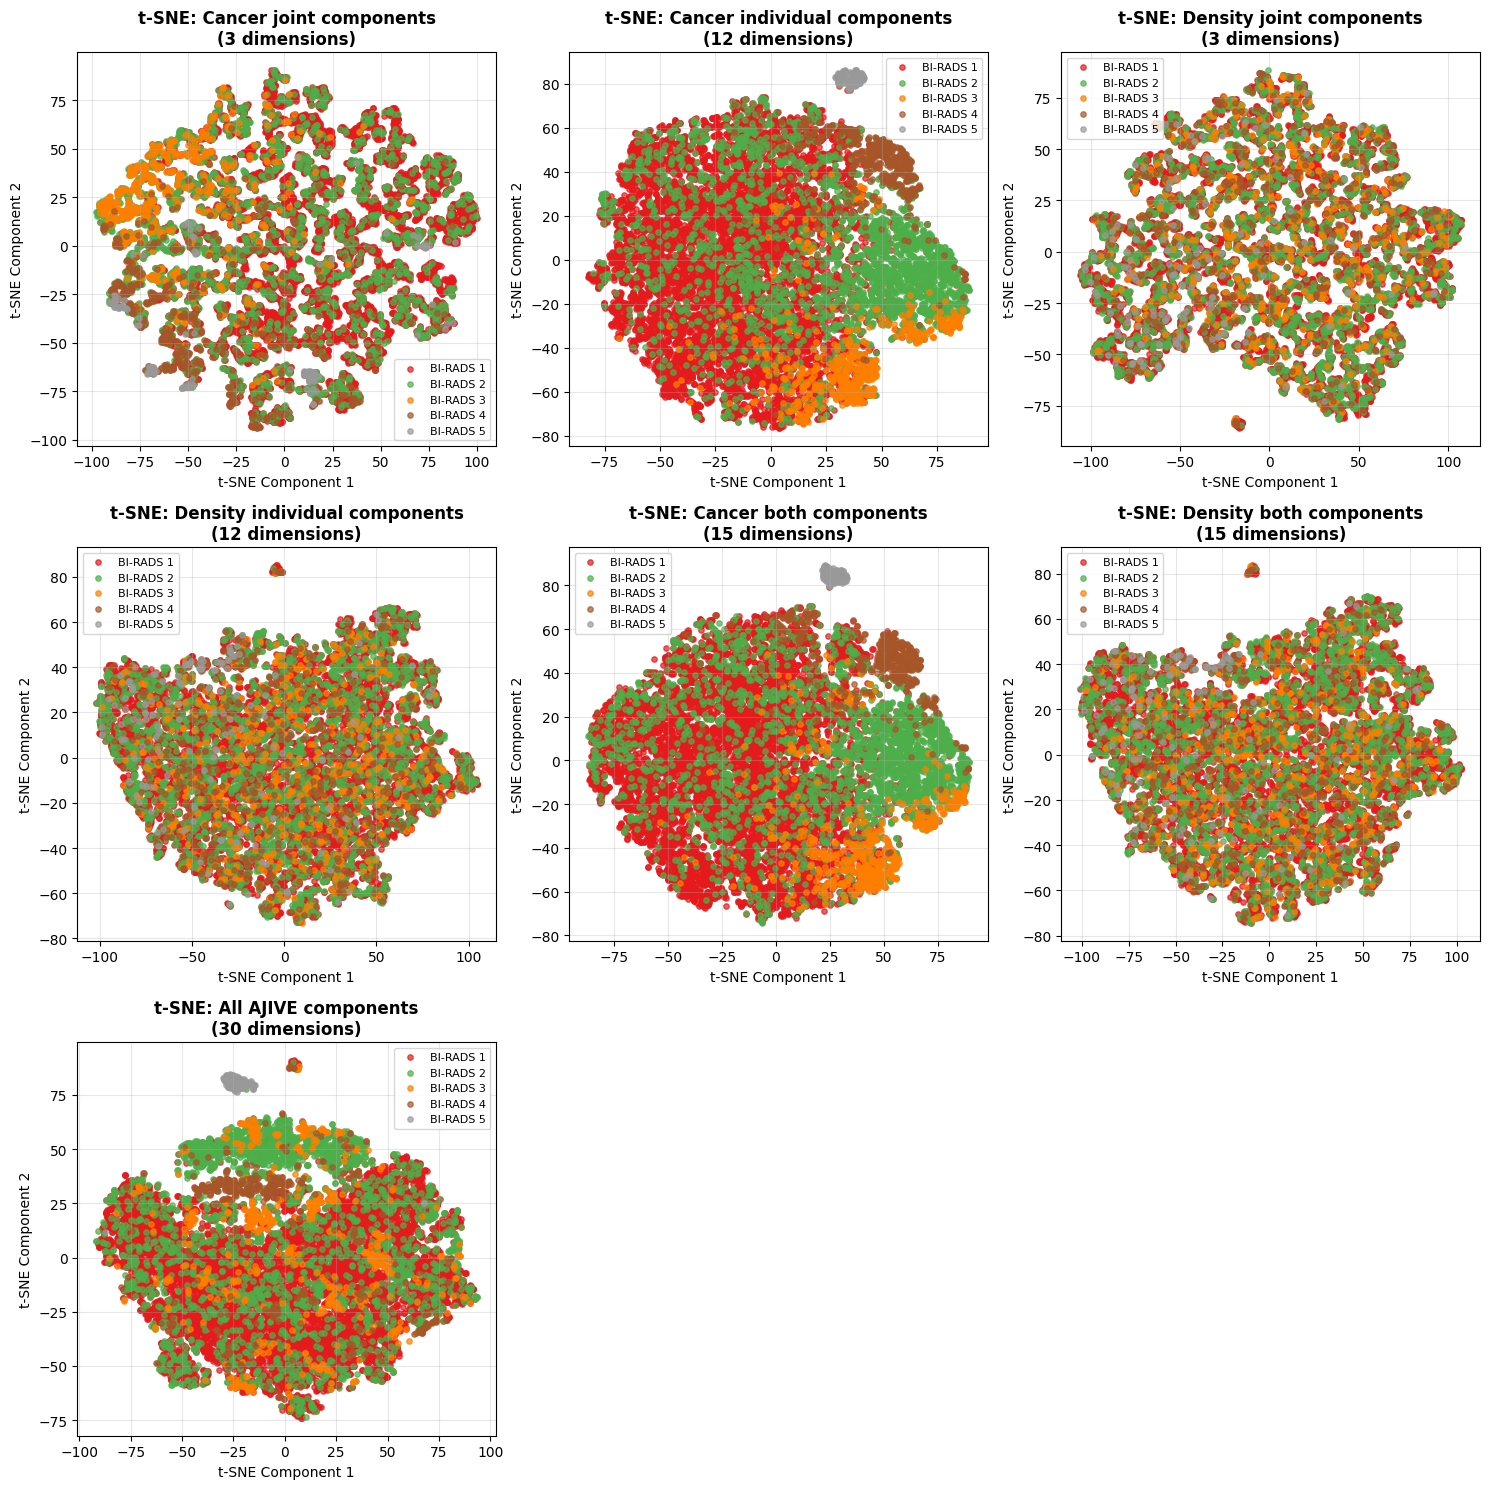

In [12]:
create_comprehensive_tsne_comparison(feature_sets, train_cancer_labels, split_to_plot='train')

Computing t-SNE for Cancer joint components...
Computing t-SNE for Cancer individual components...
Computing t-SNE for Density joint components...
Computing t-SNE for Density individual components...
Computing t-SNE for Cancer both components...
Computing t-SNE for Density both components...
Computing t-SNE for All AJIVE components...


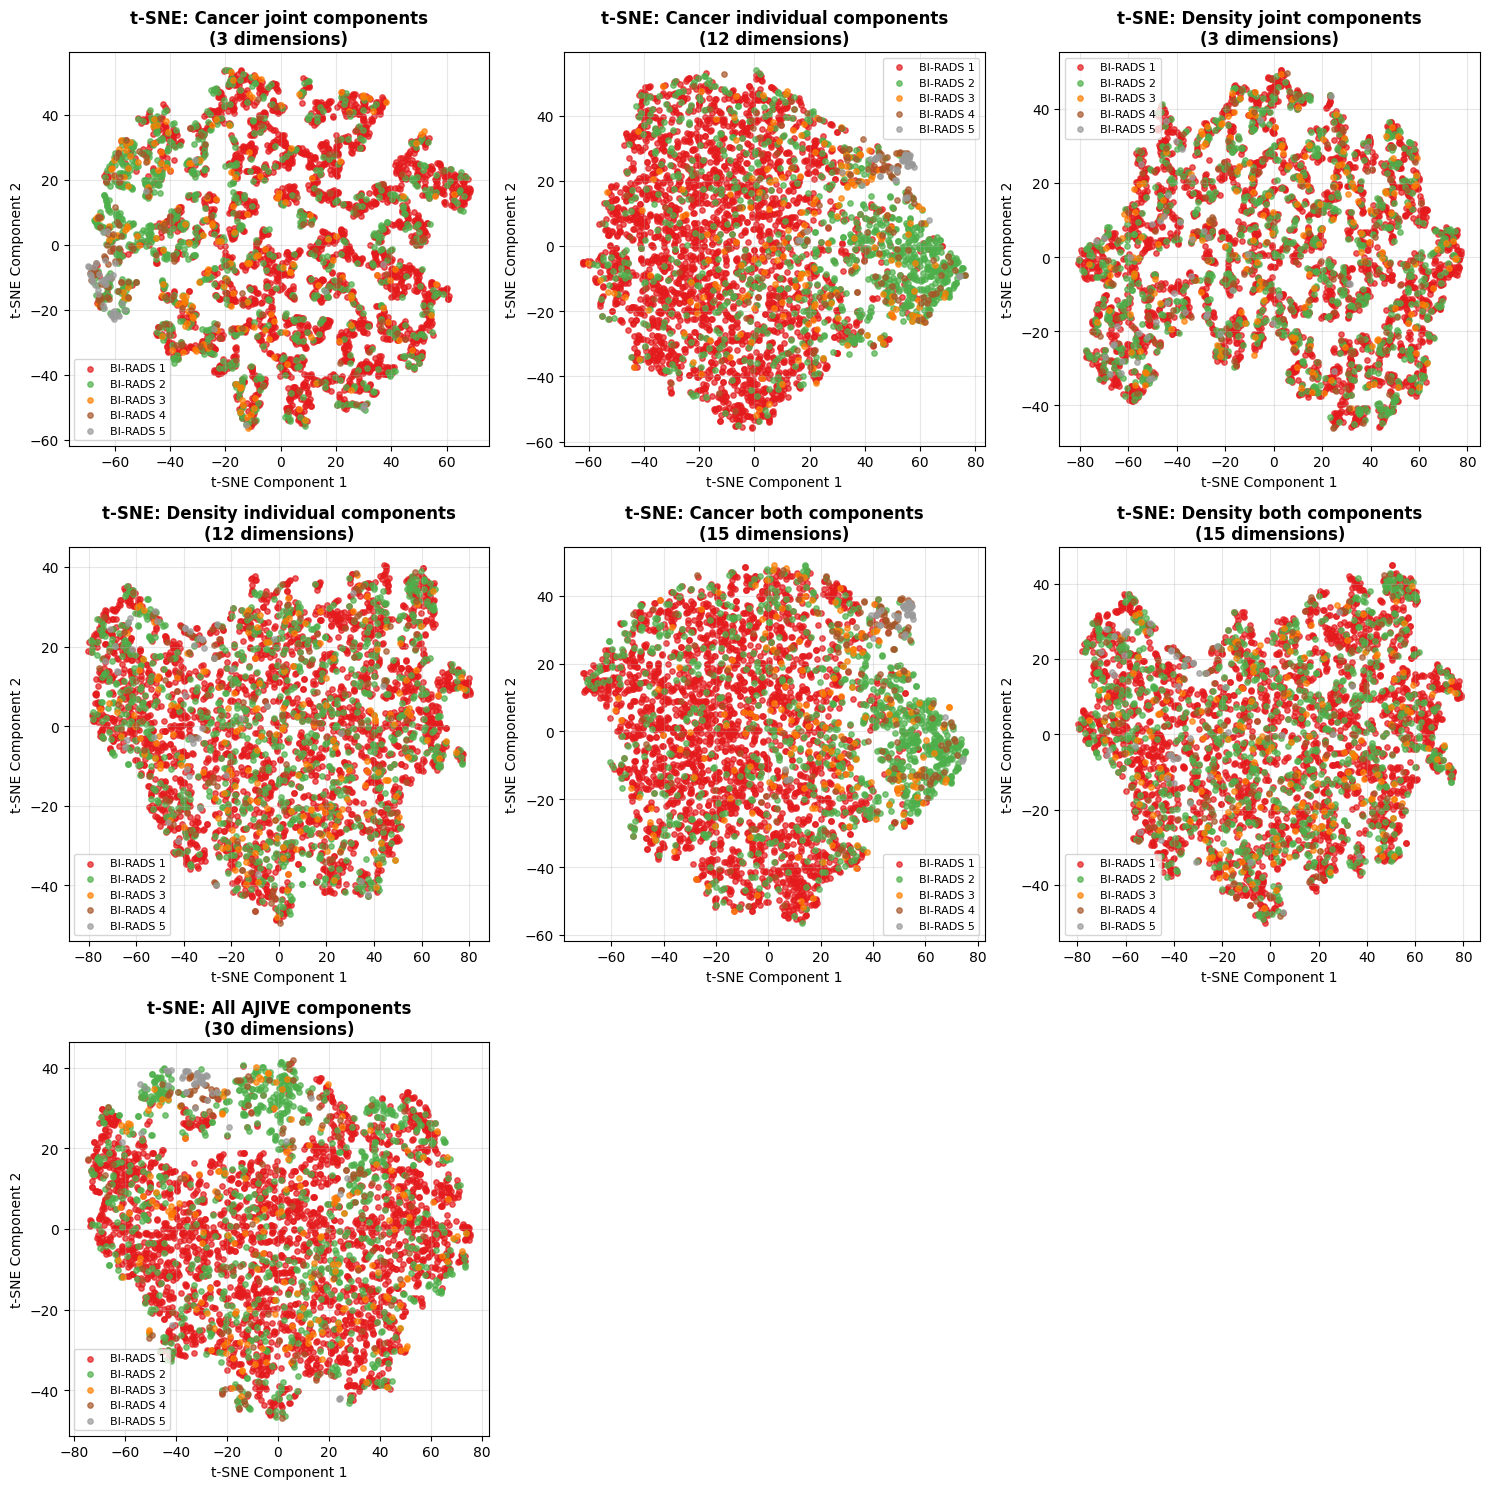

In [13]:
create_comprehensive_tsne_comparison(feature_sets, test_cancer_labels, split_to_plot='test')

In [14]:
all_results = compare_feature_transformations_svm_clean(feature_sets, label_sets)


Comparing Feature Transformations with RBF SVM...

[1/7] 🔍 Cancer joint components
Dimensions: 3
--------------------------------------------------
 Accuracy: 0.3181 | F1: 0.3418

[2/7] 🔍 Cancer individual components
Dimensions: 12
--------------------------------------------------
 Accuracy: 0.4269 | F1: 0.4763

[3/7] 🔍 Density joint components
Dimensions: 3
--------------------------------------------------
 Accuracy: 0.2000 | F1: 0.1606

[4/7] 🔍 Density individual components
Dimensions: 12
--------------------------------------------------
 Accuracy: 0.2016 | F1: 0.1641

[5/7] 🔍 Cancer both components
Dimensions: 15
--------------------------------------------------
 Accuracy: 0.4275 | F1: 0.4790

[6/7] 🔍 Density both components
Dimensions: 15
--------------------------------------------------
 Accuracy: 0.2011 | F1: 0.1632

[7/7] 🔍 All AJIVE components
Dimensions: 30
--------------------------------------------------
 Accuracy: 0.4264 | F1: 0.4759

 Execution completed: 7 evaluatio

In [15]:
print("\n Final Summary:")
print(f"Total results: {len(all_results)}")
for i, result in enumerate(all_results):
    print(f"  {i+1}. {result['feature_name']}: F1={result['test_f1_macro']:.4f}")


 Final Summary:
Total results: 7
  1. Cancer joint components: F1=0.3418
  2. Cancer individual components: F1=0.4763
  3. Density joint components: F1=0.1606
  4. Density individual components: F1=0.1641
  5. Cancer both components: F1=0.4790
  6. Density both components: F1=0.1632
  7. All AJIVE components: F1=0.4759


In [16]:
test_cancer_predictions = np.argmax(test_cancer_logits, axis=1)

test_f1_macro = f1_score(test_cancer_predictions, test_cancer_labels, average='macro')
print(f"7. Classification by the NN: {test_f1_macro:.4f}")



7. Classification by the NN: 0.4686


In [17]:
aj_temp = AJIVE(init_signal_ranks=[250, 250], n_jobs=4, center=True)
aj_temp.fit([train_cancer_features, train_dens_features])
aj_temp.summary()

'AJIVE, joint rank: 98, view 0 indiv rank: 195, view 1 indiv rank: 197'

***
# Looking into how init_rank affects AJIVE projections

In [ ]:
results = []
init_ranks = np.arange(128, 256, 10)
for i, init_rank in tqdm.tqdm(enumerate(init_ranks), total=len(init_ranks), desc="AJIVE with different ranks"):
    aj_temp = AJIVE(init_signal_ranks=[init_rank, init_rank], n_jobs=4, center=True)
    aj_temp.fit([train_cancer_features, train_dens_features])
    
    # Check if there are any joint components found
    if not aj_temp.common_:
        results.append({
            'init_rank': init_rank,
            'ranks': 0,
            'all_results': None
        })
        continue
        
    feature_sets_temp = get_ajive_projections(aj_temp, train_cancer_features, val_cancer_features, test_cancer_features, train_dens_features, val_dens_features, test_dens_features)
    
    all_results_temp = compare_feature_transformations_svm_clean(feature_sets_temp, label_sets, verbose = False)
    
    results.append({
        'init_rank': init_rank,
        'ranks': aj_temp.get_ranks(),
        'all_results': all_results_temp
    })
    

AJIVE with different ranks: 100%|██████████| 13/13 [3:05:32<00:00, 856.34s/it] 


In [18]:
results_df = pd.DataFrame(results)

# For metrics only (excluding arrays), with missing value handling
result_list = []

for idx, row in results_df.iterrows():
    init_rank = row['init_rank']
    ranks = str(row['ranks'])
    
    # Check if all_results is missing or None
    if row['all_results'] is None or (isinstance(row['all_results'], float) and pd.isna(row['all_results'])):
        # Create a row with just init_rank and ranks, other columns will be NaN
        new_row = {
            'init_rank': init_rank,
            'ranks': ranks,
        }
        result_list.append(new_row)
        continue
    
    # Check if all_results is empty list
    if isinstance(row['all_results'], list) and len(row['all_results']) == 0:
        new_row = {
            'init_rank': init_rank,
            'ranks': ranks,
        }
        result_list.append(new_row)
        continue
    
    new_row = {
        'init_rank': init_rank,
        'ranks': ranks,
    }
    # Process each result in the list
    for result_dict in row['all_results']:
        feature_name = result_dict['feature_name']
        
        new_row.update({
            f"{feature_name}_dims": result_dict['feature_dims'],
            f"{feature_name}_acc": result_dict['test_acc_macro'],
            f"{feature_name}_f1_macro": result_dict['test_f1_macro'],
        })
    result_list.append(new_row)

final_df = pd.DataFrame(result_list)

NameError: name 'results' is not defined

In [51]:
final_df

,init_rank,ranks,Cancer joint components_dims,Cancer joint components_acc,Cancer joint components_f1_macro,Cancer individual components_dims,Cancer individual components_acc,Cancer individual components_f1_macro,Density joint components_dims,Density joint components_acc,...,Density individual components_f1_macro,Cancer both components_dims,Cancer both components_acc,Cancer both components_f1_macro,Density both components_dims,Density both components_acc,Density both components_f1_macro,All AJIVE components_dims,All AJIVE components_acc,All AJIVE components_f1_macro
0,5,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,7,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11,"(1, [10, 10])",1.0,0.269342,0.246404,10.0,0.411795,0.461045,1.0,0.200000,...,0.161003,11.0,0.418661,0.470061,11.0,0.200214,0.161003,22.0,0.419374,0.468038
4,13,"(1, [12, 12])",1.0,0.256373,0.233280,12.0,0.424629,0.476912,1.0,0.200000,...,0.163214,13.0,0.423842,0.475676,13.0,0.201136,0.163192,26.0,0.424564,0.473273
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,208,"(92, [154, 155])",92.0,0.402826,0.445734,154.0,0.399048,0.444066,92.0,0.244886,...,0.223465,246.0,0.405470,0.450466,247.0,0.245560,0.244327,493.0,0.405392,0.447899
71,218,"(92, [164, 165])",92.0,0.397670,0.441185,164.0,0.398026,0.443142,92.0,0.240110,...,0.222773,256.0,0.407951,0.451985,257.0,0.246277,0.245595,513.0,0.402259,0.445517
72,228,"(93, [173, 177])",93.0,0.398544,0.441460,173.0,0.398324,0.443593,93.0,0.240613,...,0.224352,266.0,0.402961,0.447348,270.0,0.241994,0.239190,536.0,0.400580,0.443461
73,238,"(95, [184, 186])",95.0,0.398409,0.441771,184.0,0.400681,0.446697,95.0,0.240260,...,0.224352,279.0,0.400880,0.446488,281.0,0.237507,0.231906,560.0,0.397749,0.438028


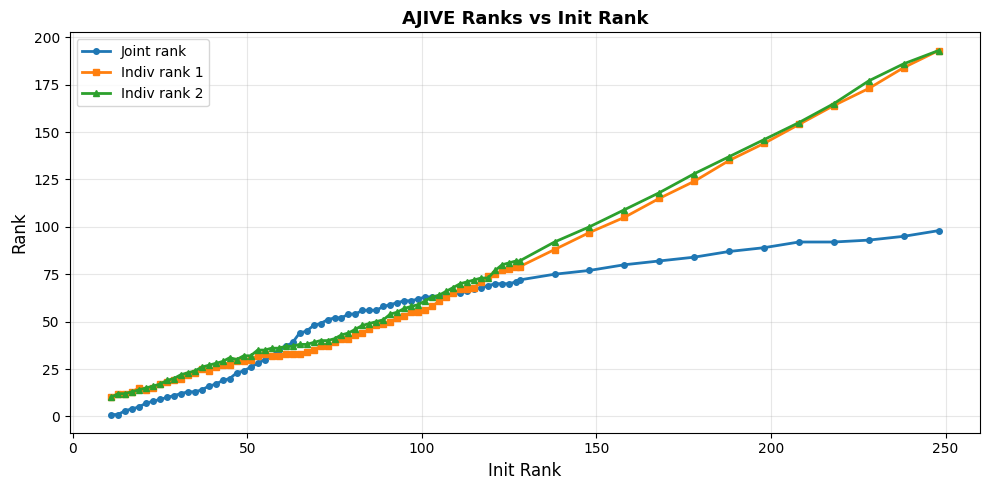

In [52]:
data = {'init_rank': [], 'joint': [], 'indiv1': [], 'indiv2': []}

for idx, row in results_df.iterrows():
    if row['ranks'] == 0:
        continue
    joint_rank, indiv_ranks = row['ranks']
    data['init_rank'].append(row['init_rank'])
    data['joint'].append(joint_rank)
    data['indiv1'].append(indiv_ranks[0])
    data['indiv2'].append(indiv_ranks[1])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(data['init_rank'], data['joint'], 'o-', label='Joint rank', linewidth=2, markersize=4)
ax.plot(data['init_rank'], data['indiv1'], 's-', label='Indiv rank 1', linewidth=2, markersize=4)
ax.plot(data['init_rank'], data['indiv2'], '^-', label='Indiv rank 2', linewidth=2, markersize=4)

ax.set_xlabel('Init Rank', fontsize=12)
ax.set_ylabel('Rank', fontsize=12)
ax.set_title('AJIVE Ranks vs Init Rank', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

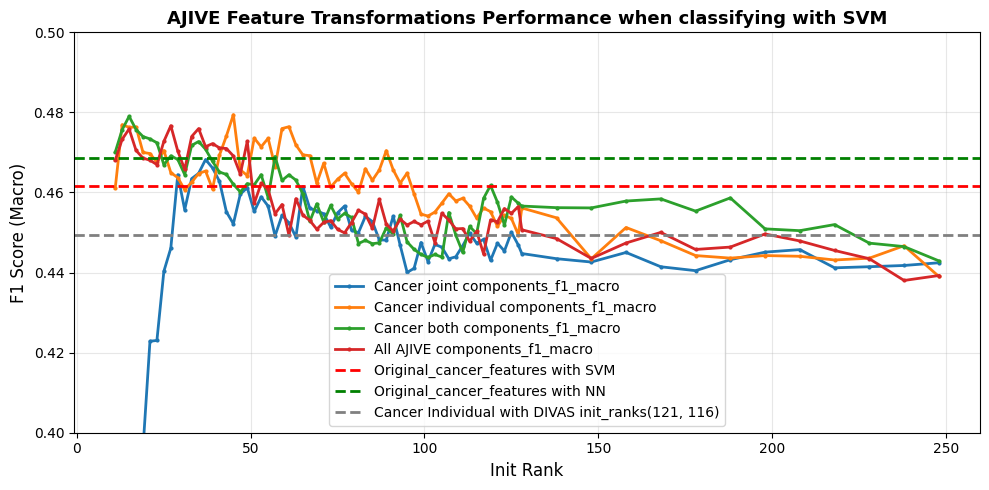

In [67]:
fig, ax = plt.subplots(figsize=(10, 5))

init_ranks_sorted = sorted(results_df['init_rank'].unique())
cols = ['Cancer joint components_f1_macro', 'Cancer individual components_f1_macro', 'Cancer both components_f1_macro', 'All AJIVE components_f1_macro']

for col in cols:
    values = [final_df[final_df['init_rank'] == ir][col].mean() for ir in init_ranks_sorted]
    ax.plot(init_ranks_sorted, values, marker='o', linewidth=2, label=col, markersize=2)

ax.axhline(y=0.4617, color='red', linestyle='--', linewidth=2, label='Original_cancer_features with SVM')
ax.axhline(y=0.4686, color='green', linestyle='--', linewidth=2, label='Original_cancer_features with NN')
ax.axhline(y=0.4495, color='gray', linestyle='--', linewidth=2, label='Cancer Individual with DIVAS init_ranks(121, 116)')
ax.set_xlabel('Init Rank', fontsize=12)
ax.set_ylabel('F1 Score (Macro)', fontsize=12)
ax.set_ylim(0.4, 0.5)
ax.set_title('AJIVE Feature Transformations Performance when classifying with SVM', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
divas = PyDIVAS()
data_blocks = {'cancer_features': train_cancer_features,
               'density_features': train_dens_features}
Phase1 = divas.run_Phase1(data_blocks, nsim=100)

In [ ]:
divas.result

### resulting divas init_ranks : 121 116 (for all observations from training dataset)

In [62]:
aj_temp = AJIVE(init_signal_ranks=[121, 116], n_jobs=4, center=True)
aj_temp.fit([train_cancer_features, train_dens_features])
    

AJIVE(init_signal_ranks=[121, 116], n_jobs=4)

In [64]:
feature_sets_temp = get_ajive_projections(aj_temp, train_cancer_features, val_cancer_features, test_cancer_features, train_dens_features, val_dens_features, test_dens_features)

all_results_temp = compare_feature_transformations_svm_clean(feature_sets_temp, label_sets, verbose = False)



In [ ]:
all_results_temp

***
# Doing AJIVE on subsets of training data and concatenating the projections

In [19]:
train_cancer_mask_correct = train_cancer_labels == np.argmax(train_cancer_logits, axis=1)


In [20]:
arr = np.arange(1, 6)
i, j = np.triu_indices(len(arr), k=1)

pairs = np.column_stack((arr[i], arr[j]))

train_cancer_mask_correct = train_cancer_labels == np.argmax(train_cancer_logits, axis=1)
splits = []

for idx, pair in enumerate(pairs):
    temp_mask = np.isin(train_cancer_labels, pair)
    temp_mask = (train_cancer_mask_correct & temp_mask)
    
    aj_temp = AJIVE(init_signal_ranks=[15, 15], n_jobs=4, center=True)
    aj_temp.fit([train_cancer_features[temp_mask], train_dens_features[temp_mask]])
    print(f"AJIVE for pair {pair} - Ranks: {aj_temp.get_ranks()}")
    
    feature_sets_temp = get_ajive_projections(aj_temp, train_cancer_features, val_cancer_features, test_cancer_features, train_dens_features, val_dens_features, test_dens_features)
    canc_ind = feature_sets_temp[1]
    canc_ind[0] = f'correct bi-rads {pair}'
    splits.append({
        'split': f'correct bi-rads {pair}',
        'train_mask': temp_mask,
        'ajive_module': aj_temp,
        'canc_indiv': canc_ind       
    })
    if idx == 0:
        feature_sets = feature_sets_temp
    else:
        for idx, feat_set in enumerate(feature_sets_temp):
            feature_sets[idx][1] = np.hstack([feature_sets[idx][1], feat_set[1]])
            feature_sets[idx][2] = np.hstack([feature_sets[idx][2], feat_set[2]])
            feature_sets[idx][3] = np.hstack([feature_sets[idx][3], feat_set[3]])
splits = pd.DataFrame(splits)

AJIVE for pair [1 2] - Ranks: (3, [12, 12])
AJIVE for pair [1 3] - Ranks: (3, [12, 12])
AJIVE for pair [1 4] - Ranks: (3, [12, 12])
AJIVE for pair [1 5] - Ranks: (3, [12, 12])
AJIVE for pair [2 3] - Ranks: (2, [13, 13])
AJIVE for pair [2 4] - Ranks: (3, [12, 12])
AJIVE for pair [2 5] - Ranks: (3, [12, 12])
AJIVE for pair [3 4] - Ranks: (2, [13, 13])
AJIVE for pair [3 5] - Ranks: (4, [11, 11])
AJIVE for pair [4 5] - Ranks: (7, [8, 9])


In [108]:
splits['canc_indiv'][0][1].shape

(12800, 117)

In [21]:
res = evaluate_svm_classifier(feature_sets[1][1], train_cancer_labels, feature_sets[1][2], val_cancer_labels, feature_sets[1][3], test_cancer_labels, "Concatenated Cancer Indiv components from multiple ajive subsets")
res

({'feature_name': 'Concatenated Cancer Indiv components from multiple ajive subsets',
  'feature_dims': 117,
  'test_acc_macro': np.float64(0.4221889576844161),
  'test_f1_macro': 0.4734715840003131,
  'test_f1_weighted': 0.7212384572666061,
  'confusion_matrix': array([[2582,   69,   22,    9,    0],
         [ 518,  378,   19,   19,    0],
         [ 135,   30,   13,    8,    0],
         [  71,   43,    2,   33,    3],
         [   7,    3,    0,   15,   21]]),
  'test_predictions': array([0, 0, 1, ..., 1, 0, 0]),
  'test_labels': array([0, 0, 1, ..., 1, 0, 0])},
 SVC(probability=True, random_state=42))

In [109]:
res = compare_feature_transformations_svm_clean(splits['canc_indiv'], label_sets=label_sets)

Comparing Feature Transformations with RBF SVM...

[1/10] 🔍 correct bi-rads [1 2]
Dimensions: 117
--------------------------------------------------
 Accuracy: 0.4222 | F1: 0.4735

[2/10] 🔍 correct bi-rads [1 3]
Dimensions: 12
--------------------------------------------------
 Accuracy: 0.4268 | F1: 0.4748

[3/10] 🔍 correct bi-rads [1 4]
Dimensions: 12
--------------------------------------------------
 Accuracy: 0.4205 | F1: 0.4697

[4/10] 🔍 correct bi-rads [1 5]
Dimensions: 12
--------------------------------------------------
 Accuracy: 0.4190 | F1: 0.4638

[5/10] 🔍 correct bi-rads [2 3]
Dimensions: 13
--------------------------------------------------
 Accuracy: 0.4230 | F1: 0.4699

[6/10] 🔍 correct bi-rads [2 4]
Dimensions: 12
--------------------------------------------------
 Accuracy: 0.4191 | F1: 0.4667

[7/10] 🔍 correct bi-rads [2 5]
Dimensions: 12
--------------------------------------------------
 Accuracy: 0.4185 | F1: 0.4663

[8/10] 🔍 correct bi-rads [3 4]
Dimensions: 13

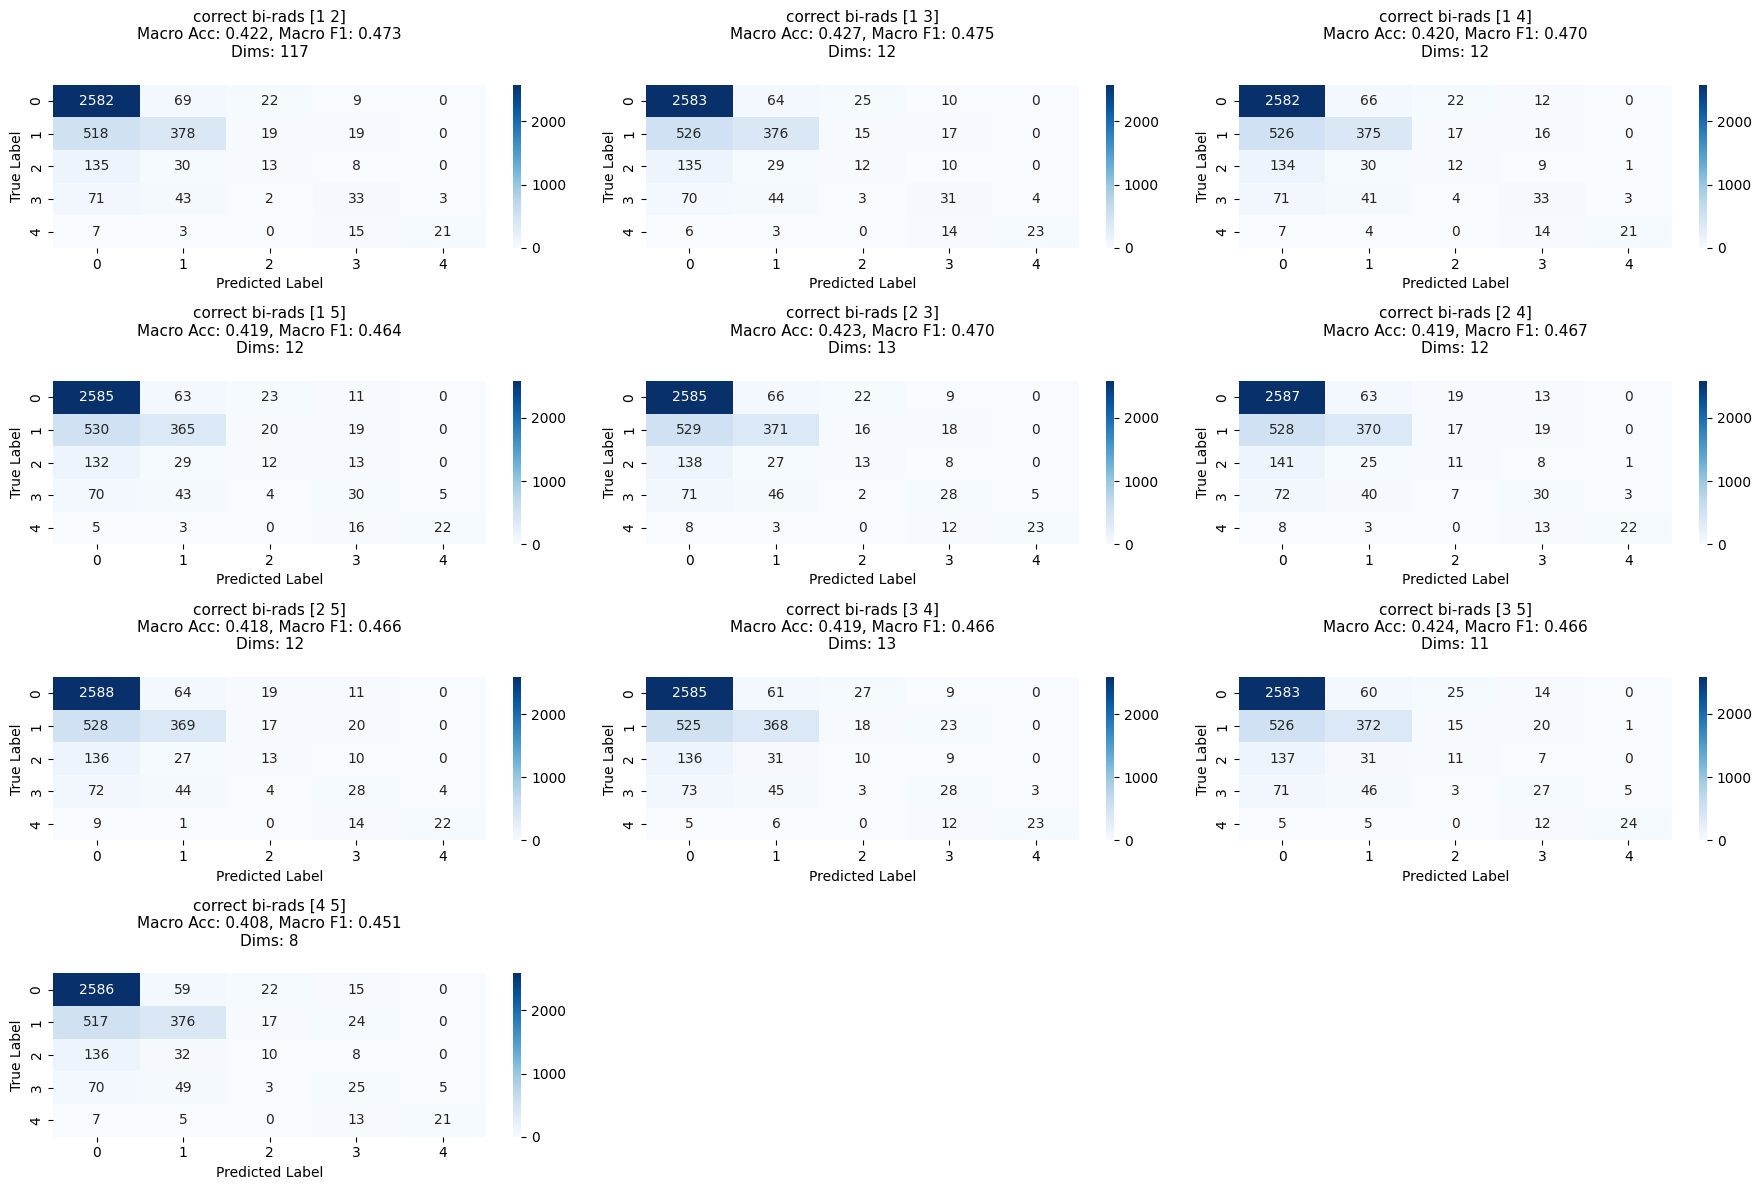

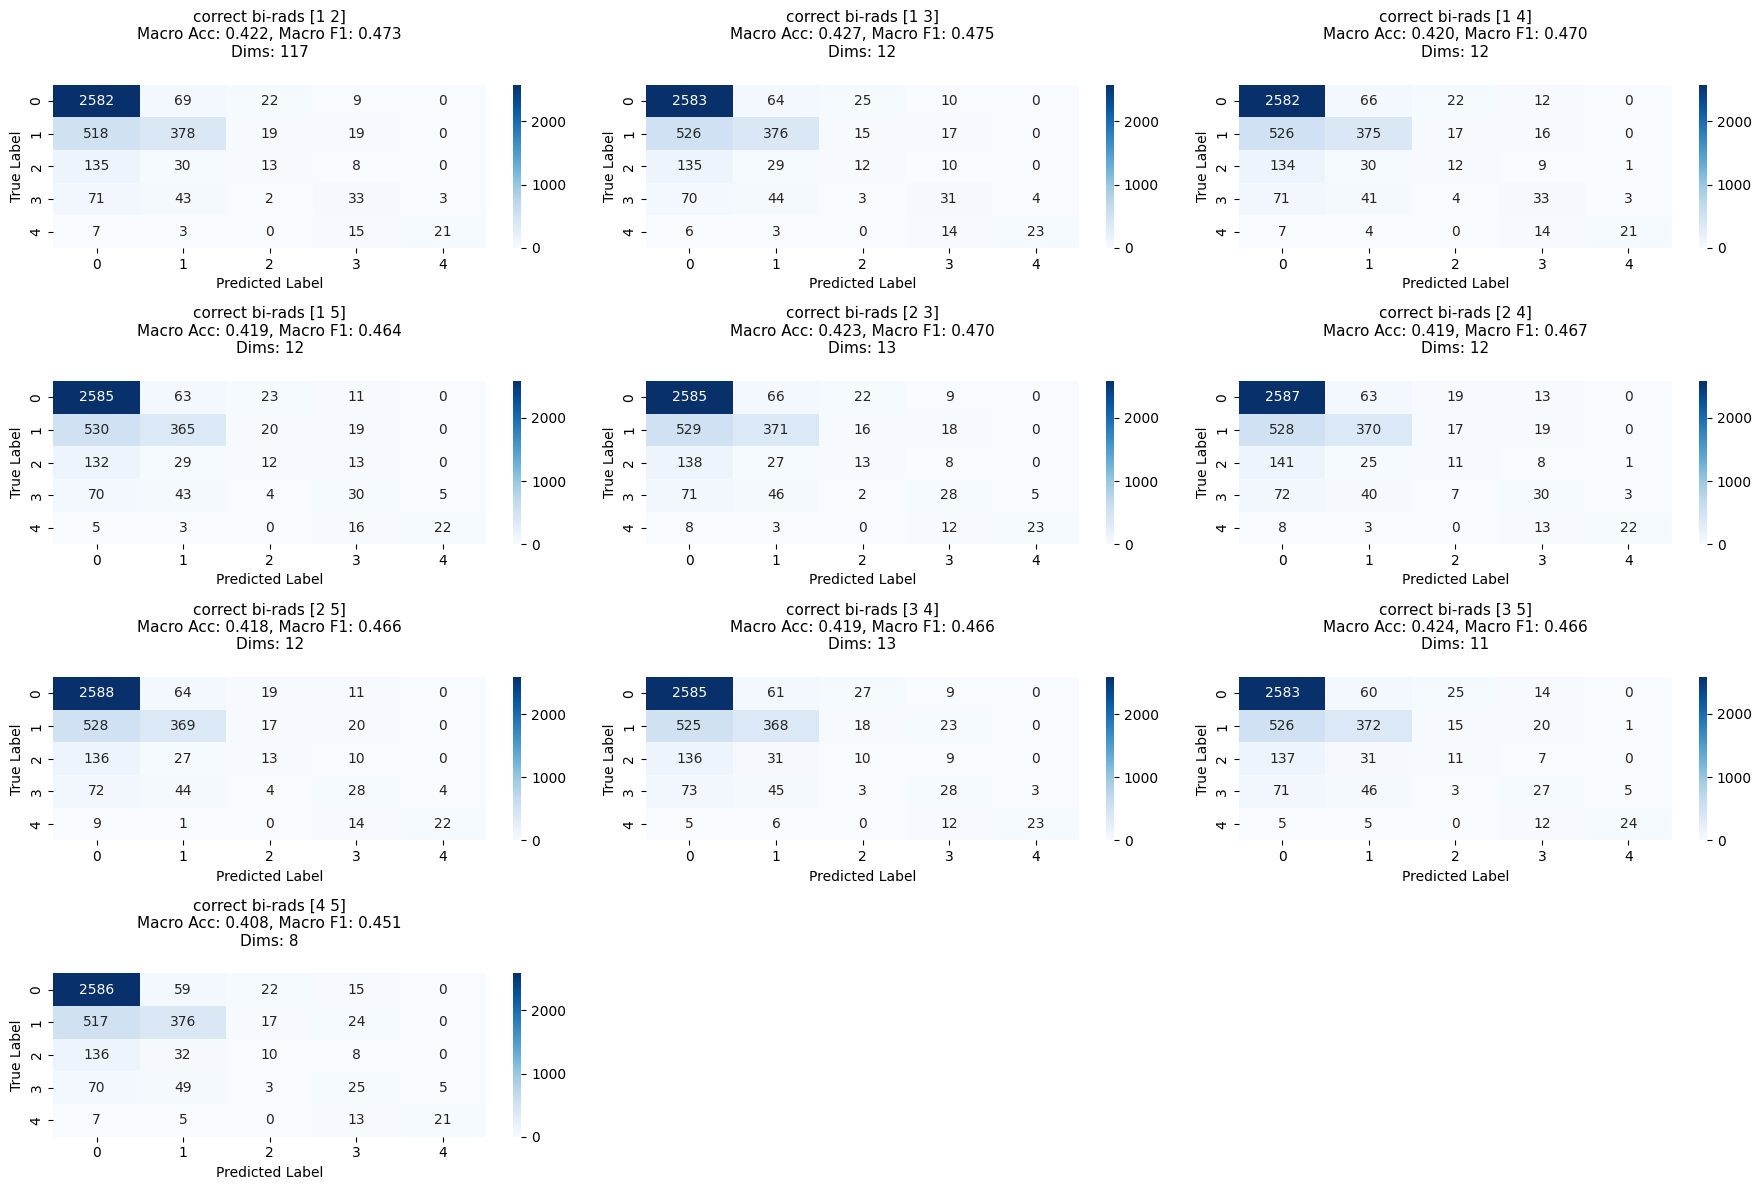

In [110]:
plot_confusion_matrices_comparison(res)

___
# Doing heatmaps

In [8]:
def visualize_grad_cam(model, image_tensor, image_label = None, target_class=None, suptitle=None, cmap='jet', 
                       denormalize=True, mean=108.3328, std=69.6431):
    """
    Visualize Grad-CAM heatmap overlaid on the input image.
    
    Args:
        model: Single_view_model instance
        image_tensor: Input image tensor of shape (1, 3, H, W) or (3, H, W)
        image_label: Ground truth label for the image (optional, used for title)
        target_class: Target class for computing gradients. If None, uses predicted class.
        cmap: Colormap for the heatmap
        denormalize: Whether to denormalize the image (default: True)
        mean: Mean used for normalization (default: 108.3328 for png dataset_zscore)
        std: Std used for normalization (default: 69.6431 for png dataset_zscore)
    
    Returns:
        fig: Matplotlib figure with the visualization
    """
    # Ensure input has batch dimension
    if image_tensor.dim() == 3:
        image_tensor = image_tensor.unsqueeze(0)
    
    # Only process the first image if batch size > 1
    if image_tensor.shape[0] > 1:
        image_tensor = image_tensor[0:1]
    
    # Generate Grad-CAM
    grad_cam, predicted_class = model.generate_grad_cam(image_tensor, target_class)
    
    # Get the original image for display and denormalize
    image_np = image_tensor[0].detach().permute(1, 2, 0).cpu().numpy()
    
    # Denormalize using dataset statistics
    if denormalize:
        image_np = image_np * std + mean
        # Normalize to [0, 1] for display
        image_np = image_np / 255.0
        image_np = np.clip(image_np, 0, 1)
    
    # Resize grad_cam to match image size
    grad_cam_resized = torch.nn.functional.interpolate(
        grad_cam.unsqueeze(1), 
        size=(image_np.shape[0], image_np.shape[1]), 
        mode='bilinear', 
        align_corners=False
    )
    grad_cam_resized = grad_cam_resized.squeeze(1)[0].numpy()
    
    # Create visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original image
    axes[0].imshow(image_np, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    # Grad-CAM heatmap
    im1 = axes[1].imshow(grad_cam_resized, cmap=cmap)
    axes[1].set_title('Grad-CAM Heatmap')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1])
    
    # Overlay
    axes[2].imshow(image_np, cmap='gray')
    im2 = axes[2].imshow(grad_cam_resized, cmap=cmap, alpha=0.5)
    axes[2].set_title(f'Overlay (Pred: Class {predicted_class.item()}, True: Class {image_label})')
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2])
    
    if suptitle is not None:
        plt.suptitle(suptitle)
    
    plt.tight_layout()
    
    return fig

def get_weighted_cam(model, image_tensor, cam_weights, image_label=None, plot = False, suptitle = None,cmap='jet', 
                       denormalize=True, mean=108.3328, std=69.6431):
    """
    Return Weighted-CAM heatmap: cam_weights (eg. ajive loadings) are used instead of gradients to weigh the activation mappings.
    
    Args:
        model: Single_view_model instance
        image_tensor: Input image tensor of shape (1, 3, H, W) or (3, H, W)
        cam_weights: One mode of variation loading - a direction in the feature space (512)
        plot: Whether to plot or not
        cmap: Colormap for the heatmap
        denormalize: Whether to denormalize the image (default: True)
        mean: Mean used for normalization (default: 108.3328 for png dataset_zscore)
        std: Std used for normalization (default: 69.6431 for png dataset_zscore)
    
    Returns:
        fig: Matplotlib figure with the visualization
    """
    # Ensure input has batch dimension
    if image_tensor.dim() == 3:
        image_tensor = image_tensor.unsqueeze(0)
    
    # Only process the first image if batch size > 1
    if image_tensor.shape[0] > 1:
        image_tensor = image_tensor[0:1]
    
    # Generate Grad-CAM
    weighted_cam, predicted_class, ajive_score = model.generate_weighted_cam(image_tensor, cam_weights)
    
    # Get the original image for display and denormalize
    image_np = image_tensor[0].detach().permute(1, 2, 0).cpu().numpy()
    
    # Denormalize using dataset statistics
    if denormalize:
        image_np = image_np * std + mean
        # Normalize to [0, 1] for display
        image_np = image_np / 255.0
        image_np = np.clip(image_np, 0, 1)
    
    # Resize grad_cam to match image size
    weighted_cam_resized = torch.nn.functional.interpolate(
        weighted_cam.unsqueeze(1), 
        size=(image_np.shape[0], image_np.shape[1]), 
        mode='bilinear', 
        align_corners=False
    )
    weighted_cam_resized = weighted_cam_resized.squeeze(1)[0].numpy()
    
    if plot:
        # Create visualization
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # Original image
        axes[0].imshow(image_np, cmap='gray')
        axes[0].set_title('Original Image')
        axes[0].axis('off')
        
        # Weighted-CAM heatmap
        im1 = axes[1].imshow(weighted_cam_resized, cmap=cmap)
        axes[1].set_title('Weighted-CAM Heatmap')
        axes[1].axis('off')
        plt.colorbar(im1, ax=axes[1])
        
        # Overlay
        axes[2].imshow(image_np, cmap='gray')
        im2 = axes[2].imshow(weighted_cam_resized, cmap=cmap, alpha=0.5)
        axes[2].set_title(f'Overlay (Pred: Class {predicted_class.item()}, True: Class {image_label })')
        axes[2].axis('off')
        plt.colorbar(im2, ax=axes[2])
        if suptitle is not None:
            plt.suptitle(suptitle)
        
        plt.tight_layout()
        
        plt.show()
    return weighted_cam_resized, predicted_class.item(), ajive_score.item()

def get_weighted_cam_from_dataset(model, dataset, annot_row, cam_weights, plot = False):
    """
    Convenience function to get weighted CAM directly from dataset and annotation row.
    """
    dataloader_idx = np.where(dataset.image_ids == annot_row['image_id'])[0][0]
    
    image_tensor, label1, label2 = dataset[dataloader_idx]
    
    
    # Get weighted CAM
    weighted_cam, predicted_class, ajive_score = get_weighted_cam(model, image_tensor, cam_weights, plot=plot, image_label=label1 if model.task == 1 else label2)
    
    return weighted_cam, predicted_class, label1, label2, ajive_score, image_tensor

def calculate_bbox_probability_mass(saliency_map, annot_row):
    """
    Calculate what fraction of total saliency (probability mass) falls within the bounding box.
    
    This is a threshold-free metric that directly measures how much attention 
    the model puts on the annotated region.
    
    Parameters:
    -----------
    saliency_map : np.ndarray
        Normalized saliency map (should be in [0, 1] range)
    annot_row : pd.Series
        Annotation row containing bounding box coordinates
    
    Returns:
    --------
    bbox_mass : float
        Fraction of total saliency mass within the bounding box [0, 1]
    bbox_mask : np.ndarray
        Binary bounding box mask
    mean_inside : float
        Average saliency inside the bbox
    mean_outside : float
        Average saliency outside the bbox
    mass_ratio : float
        Ratio of mean_inside / mean_outside (how much more attention inside vs outside)
    """
    height, width = saliency_map.shape
    
    # Normalize saliency to be a probability distribution (sum to 1)
    saliency_prob = saliency_map / saliency_map.sum() if saliency_map.sum() > 0 else saliency_map
    
    # Create bounding box mask
    bbox_mask = np.zeros((height, width), dtype=bool)
    
    # Extract and scale bounding box coordinates
    x_min = int(annot_row['resized_xmin'] * width / 912)
    y_min = int(annot_row['resized_ymin'] * height / 1520)
    x_max = int(annot_row['resized_xmax'] * width / 912)
    y_max = int(annot_row['resized_ymax'] * height / 1520)
    
    # Ensure coordinates are within bounds
    x_min = max(0, min(x_min, width - 1))
    x_max = max(0, min(x_max, width))
    y_min = max(0, min(y_min, height - 1))
    y_max = max(0, min(y_max, height))
    
    # Fill the bounding box mask
    bbox_mask[y_min:y_max, x_min:x_max] = True
    
    if saliency_map.sum() == 0:
        print("Warning: Saliency map has zero total mass. Returning zeros for all metrics.")
        return bbox_mask, 0, 0, 0, 0, False
    
    # Calculate probability mass within bbox
    bbox_mass = saliency_prob[bbox_mask].sum()
    
    # Calculate enrichment factor (how much more attention than expected by size alone)
    bbox_area = bbox_mask.sum()
    total_area = saliency_map.size
    expected_mass = bbox_area / total_area  # Expected mass if uniform distribution
    enrichment = bbox_mass / expected_mass if expected_mass > 0 else 0
    
    # Calculate additional metrics
    mean_inside = saliency_prob[bbox_mask].mean() if bbox_mask.sum() > 0 else 0
    mean_outside = saliency_prob[~bbox_mask].mean() if (~bbox_mask).sum() > 0 else 0
    mass_ratio = mean_inside / mean_outside if mean_outside > 0 else np.inf
    
    max_loc = np.unravel_index(saliency_map.argmax(), saliency_map.shape)    
    pointing_game = bbox_mask[max_loc]    

    return bbox_mask, enrichment, mean_inside, mean_outside, mass_ratio, pointing_game

def plot_probability_mass_ajive(model, dataset, annot_row, loadings_vector):
    """
    Visualize probability mass analysis for a given annotation.
    
    Creates a 3-panel visualization showing:
    1. Normalized saliency map
    2. Probability distribution with bbox overlay
    3. Bbox region highlighted vs outside
    
    Parameters:
    -----------
    model : pytorch model
        The model to generate saliency from
    dataset : Dataset
        The dataset containing the images
    annot_row : pd.Series
        Annotation row containing patient_id, view, and bbox coordinates
    """
    # Generate saliency map
    saliency_map, predicted_class, y1_label, y2_label, ajive_score, _ = get_weighted_cam_from_dataset(model, dataset, annot_row, loadings_vector)
    
    # Calculate metrics
    bbox_mask, enrichment, mean_inside, mean_outside, mass_ratio, pointing_game = calculate_bbox_probability_mass(
        saliency_map, annot_row
    )
    
    # Normalize to probability distribution for visualization
    saliency_prob = saliency_map / saliency_map.sum()
    
    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # 1. Original saliency as heatmap
    im1 = axes[0].imshow(saliency_map, cmap='hot')
    axes[0].set_title('Normalized Saliency Map')
    axes[0].axis('off')
    plt.colorbar(im1, ax=axes[0], fraction=0.046)
    
    # 2. Probability distribution with bbox overlay
    im2 = axes[1].imshow(saliency_prob, cmap='hot')
    # Draw bbox rectangle
    y_min, y_max = np.where(bbox_mask)[0][[0, -1]]
    x_min, x_max = np.where(bbox_mask)[1][[0, -1]]
    rect = Rectangle((x_min, y_min), x_max-x_min, y_max-y_min, 
                     linewidth=2, edgecolor='cyan', facecolor='none', linestyle='--')
    axes[1].add_patch(rect)
    axes[1].set_title(f'Probability Distribution\nEnrichment: {enrichment:.2f}x (cyan bbox)')
    axes[1].axis('off')
    plt.colorbar(im2, ax=axes[1], fraction=0.046)
    
    # 3. Show bbox region vs outside
    overlay = np.zeros((*saliency_map.shape, 3))
    # Make bbox region show the actual saliency values
    overlay[bbox_mask] = plt.cm.hot(saliency_prob[bbox_mask] / saliency_prob.max())[:, :3]
    # Make outside region dimmed
    overlay[~bbox_mask] = plt.cm.gray(saliency_prob[~bbox_mask] / saliency_prob.max())[:, :3] * 0.3
    
    axes[2].imshow(overlay)
    axes[2].set_title(f'Bbox Region Highlighted\nMass-Ratio: {mass_ratio:.1f}x more attention')
    axes[2].axis('off')
    
    # Mark max saliency point
    max_loc = np.unravel_index(saliency_map.argmax(), saliency_map.shape)
    max_y, max_x = max_loc
    for ax in axes:
        ax.plot(max_x, max_y, 'g*', markersize=15, markeredgecolor='white', markeredgewidth=1)
    
    fig.suptitle(f'Probability Mass Analysis (No Thresholding)\nAnnotation class: {annot_row["finding_category"]}, BI-RADS: {y1_label}, Density: {y2_label}, Predicted Class: {predicted_class}', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return enrichment, mass_ratio, pointing_game

def process_all_annotations_ajive(model, dataset, annot_df, loadings_vector):
    results = []
    problematic_indices = []
    for idx, row in tqdm.tqdm(annot_df.iterrows(), total=len(annot_df), desc="Processing annotations"):
        saliency_map, predicted_class, y1_label, y2_label, ajive_score, _ = get_weighted_cam_from_dataset(model, dataset, row, loadings_vector)
        if saliency_map.sum() == 0:
            problematic_indices.append(idx)
        
        # Calculate probability mass metrics
        bbox_mask, enrichment, mean_inside, mean_outside, mass_ratio, pointing_game = calculate_bbox_probability_mass(
            saliency_map, row
        )
        
        results.append({
            'patient_id': row['patient_id'],
            'series_id': row['series_id'],
            'image_id': row['image_id'],
            'view': row['view'],
            'laterality': row['laterality'],
            'finding_category': row['finding_category'],
            'enrichment': enrichment,
            'mean_inside': mean_inside,
            'mean_outside': mean_outside,
            'mass_ratio': mass_ratio,
            'pointing_game': pointing_game,
            'BI-RADS': y1_label,
            'Density': y2_label,
            'predicted_class': predicted_class,
            'bbox_mask': bbox_mask,
            'ajive_score': ajive_score
        })
    
    results_df = pd.DataFrame(results)
    if problematic_indices:
        print(f"Found {len(problematic_indices)} annotations with zero-mass saliency in the image. Indices: {problematic_indices}")
    return results_df

def plot_probability_mass_comparison(model1, model2, dataset, annot_row, loadings_vector1, loadings_vector2, 
                                     mean=108.3328, std=69.6431, cmap='jet'):
    """
    Compare probability mass analysis between two models for a given annotation.
    
    Creates a 2x3 visualization showing the three-panel analysis (original image, 
    heatmap, and overlay) for both models.
    
    Parameters:
    -----------
    model1 : pytorch model
        The first model to generate saliency from
    model2 : pytorch model
        The second model to generate saliency from
    dataset : Dataset
        The dataset containing the images
    annot_row : pd.Series
        Annotation row containing patient_id, view, and bbox coordinates
    loadings_vector1 : np.ndarray or torch.Tensor
        Loading vector for model 1
    loadings_vector2 : np.ndarray or torch.Tensor
        Loading vector for model 2
    mean : float
        Mean for denormalization
    std : float
        Std for denormalization
    cmap : str
        Colormap for heatmap visualization
    """
    # Generate saliency maps and get image tensor
    saliency_map1, predicted_class1, y1_label, y2_label, _, image_tensor = get_weighted_cam_from_dataset(model1, dataset, annot_row, loadings_vector1)
    saliency_map2, predicted_class2, _, _, _, _ = get_weighted_cam_from_dataset(model2, dataset, annot_row, loadings_vector2)
    
    # Get the original image for display and denormalize
    image_np = image_tensor.detach().permute(1, 2, 0).cpu().numpy()
    image_np = image_np * std + mean
    image_np = image_np / 255.0
    image_np = np.clip(image_np, 0, 1)
    
    # Resize saliency maps to match image size
    saliency_map1_resized = torch.nn.functional.interpolate(
        torch.from_numpy(saliency_map1).unsqueeze(0).unsqueeze(0), 
        size=(image_np.shape[0], image_np.shape[1]), 
        mode='bilinear', 
        align_corners=False
    ).squeeze().numpy()
    
    saliency_map2_resized = torch.nn.functional.interpolate(
        torch.from_numpy(saliency_map2).unsqueeze(0).unsqueeze(0), 
        size=(image_np.shape[0], image_np.shape[1]), 
        mode='bilinear', 
        align_corners=False
    ).squeeze().numpy()
    
    # Calculate metrics for both models
    bbox_mask1, enrichment1, mean_inside1, mean_outside1, mass_ratio1, pointing_game1 = calculate_bbox_probability_mass(
        saliency_map1, annot_row
    )
    
    bbox_mask2, enrichment2, mean_inside2, mean_outside2, mass_ratio2, pointing_game2 = calculate_bbox_probability_mass(
        saliency_map2, annot_row
    )
    
    # Create figure with 2 rows, 3 columns
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # ==================== MODEL 1 (Top Row) ====================
    # Draw bbox on overlay
    y_min1, y_max1 = np.where(bbox_mask1)[0][[0, -1]]
    x_min1, x_max1 = np.where(bbox_mask1)[1][[0, -1]]
    # Scale bbox to resized image
    y_min1_scaled = int(y_min1 * image_np.shape[0] / saliency_map1.shape[0])
    y_max1_scaled = int(y_max1 * image_np.shape[0] / saliency_map1.shape[0])
    x_min1_scaled = int(x_min1 * image_np.shape[1] / saliency_map1.shape[1])
    x_max1_scaled = int(x_max1 * image_np.shape[1] / saliency_map1.shape[1])
    
    # 1. Model 1 - Original image
    axes[0, 0].imshow(image_np, cmap='gray')
    axes[0, 0].set_title('Model 1: Original Image', fontweight='bold')
    axes[0, 0].axis('off')
    
    rect1 = Rectangle((x_min1_scaled, y_min1_scaled), x_max1_scaled-x_min1_scaled, y_max1_scaled-y_min1_scaled, 
                      linewidth=2, edgecolor='cyan', facecolor='none', linestyle='--')
    axes[0, 0].add_patch(rect1)
    
    # 2. Model 1 - Heatmap
    im1 = axes[0, 1].imshow(saliency_map1_resized, cmap=cmap)
    axes[0, 1].set_title(f'Model 1: Weighted-CAM Heatmap\nEnrichment: {enrichment1:.2f}x', fontweight='bold')
    axes[0, 1].axis('off')
    plt.colorbar(im1, ax=axes[0, 1], fraction=0.046)
    
    # 3. Model 1 - Overlay
    axes[0, 2].imshow(image_np, cmap='gray')
    im2 = axes[0, 2].imshow(saliency_map1_resized, cmap=cmap, alpha=0.5)
    axes[0, 2].set_title(f'Model 1: Overlay\nMass-Ratio: {mass_ratio1:.1f}x', fontweight='bold')
    axes[0, 2].axis('off')
    plt.colorbar(im2, ax=axes[0, 2], fraction=0.046)
    
    
    rect1 = Rectangle((x_min1_scaled, y_min1_scaled), x_max1_scaled-x_min1_scaled, y_max1_scaled-y_min1_scaled, 
                      linewidth=2, edgecolor='cyan', facecolor='none', linestyle='--')
    axes[0, 2].add_patch(rect1)
    
    # Mark max saliency point for model 1
    max_loc1 = np.unravel_index(saliency_map1_resized.argmax(), saliency_map1_resized.shape)
    max_y1, max_x1 = max_loc1
    for ax in axes[0, :]:
        ax.plot(max_x1, max_y1, 'g*', markersize=15, markeredgecolor='white', markeredgewidth=1)
    
    # ==================== MODEL 2 (Bottom Row) ====================
    
    # 4. Model 2 - Original image
    axes[1, 0].imshow(image_np, cmap='gray')
    axes[1, 0].set_title('Model 2: Original Image', fontweight='bold')
    axes[1, 0].axis('off')
    
    rect2 = Rectangle((x_min1_scaled, y_min1_scaled), x_max1_scaled-x_min1_scaled, y_max1_scaled-y_min1_scaled, 
                        linewidth=2, edgecolor='cyan', facecolor='none', linestyle='--')
    axes[1, 0].add_patch(rect2)
    
    # 5. Model 2 - Heatmap
    im3 = axes[1, 1].imshow(saliency_map2_resized, cmap=cmap)
    axes[1, 1].set_title(f'Model 2: Weighted-CAM Heatmap\nEnrichment: {enrichment2:.2f}x', fontweight='bold')
    axes[1, 1].axis('off')
    plt.colorbar(im3, ax=axes[1, 1], fraction=0.046)
    
    # 6. Model 2 - Overlay
    axes[1, 2].imshow(image_np, cmap='gray')
    im4 = axes[1, 2].imshow(saliency_map2_resized, cmap=cmap, alpha=0.5)
    axes[1, 2].set_title(f'Model 2: Overlay\nMass-Ratio: {mass_ratio2:.1f}x', fontweight='bold')
    axes[1, 2].axis('off')
    plt.colorbar(im4, ax=axes[1, 2], fraction=0.046)
    
    rect2 = Rectangle((x_min1_scaled, y_min1_scaled), x_max1_scaled-x_min1_scaled, y_max1_scaled-y_min1_scaled, 
                      linewidth=2, edgecolor='cyan', facecolor='none', linestyle='--')
    axes[1, 2].add_patch(rect2)

    
    # Mark max saliency point for model 2
    max_loc2 = np.unravel_index(saliency_map2_resized.argmax(), saliency_map2_resized.shape)
    max_y2, max_x2 = max_loc2
    for ax in axes[1, :]:
        ax.plot(max_x2, max_y2, 'g*', markersize=15, markeredgecolor='white', markeredgewidth=1)
    
    # Overall title
    fig.suptitle(f'Model Comparison: Probability Mass Analysis\nAnnotation: {annot_row["finding_category"]}, BI-RADS: {y1_label} (pred: {predicted_class1}), Density: {y2_label} (pred: {predicted_class2})', 
                 fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return enrichment1, mass_ratio1, pointing_game1, enrichment2, mass_ratio2, pointing_game2




In [23]:
model_cancer.to('cpu')
model_density.to('cpu')
images, labels, densities = next(iter(dataloader.test_dataloader()))

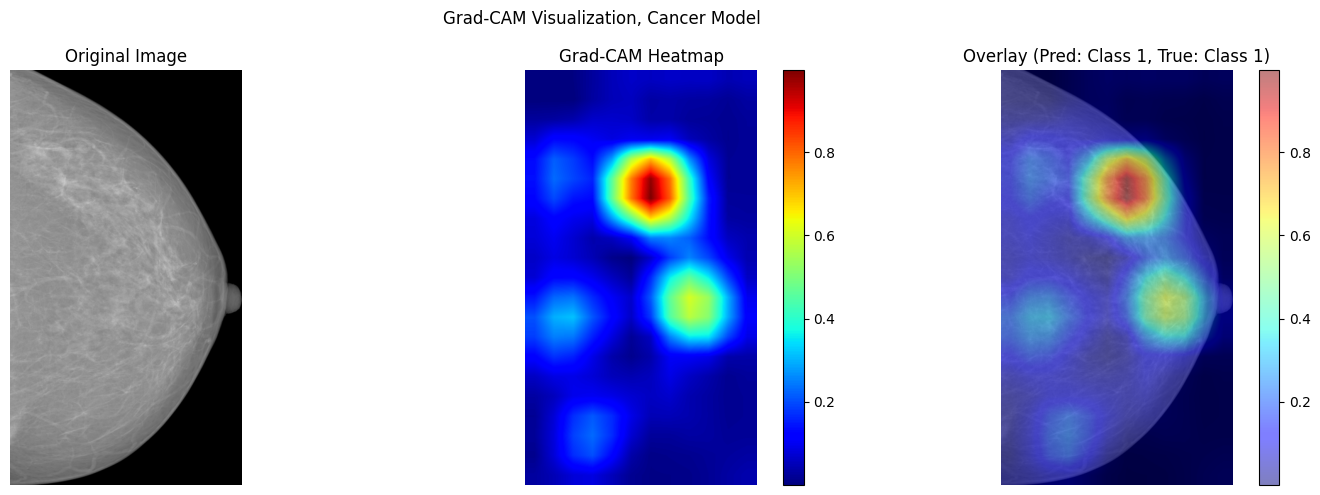

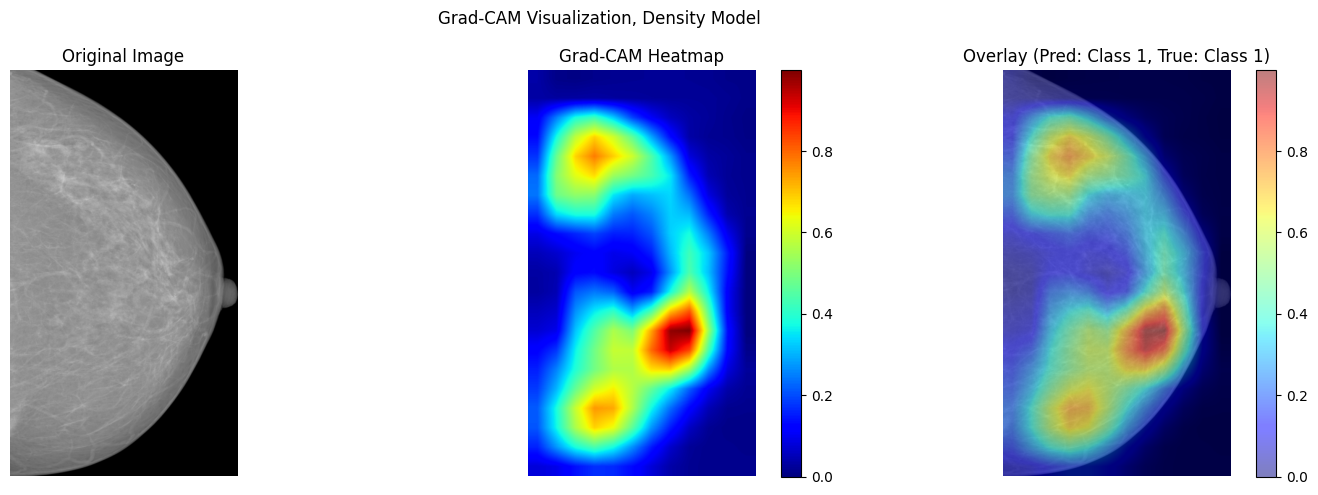

In [24]:
i = 12
# Visualize Grad-CAM
fig = visualize_grad_cam(model_cancer, images[i], labels[i], suptitle='Grad-CAM Visualization, Cancer Model',)
plt.show()
fig = visualize_grad_cam(model_density, images[i], densities[i], suptitle='Grad-CAM Visualization, Density Model',)
plt.show()

# Define loadings of interest

In [25]:
cancer_individual_first_loadings = aj.view_specific_[0].individual_.loadings_[:,0]
dens_individual_first_loadings = aj.view_specific_[1].individual_.loadings_[:,0]
cancer_joint_first_loadings = aj.view_specific_[0].joint_.loadings_[:,0]

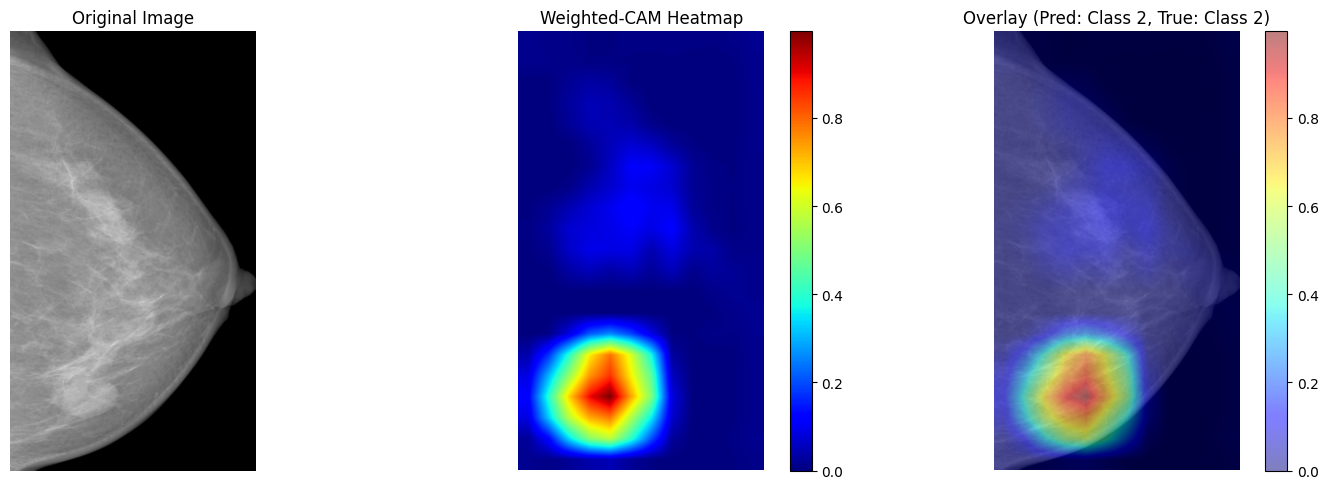

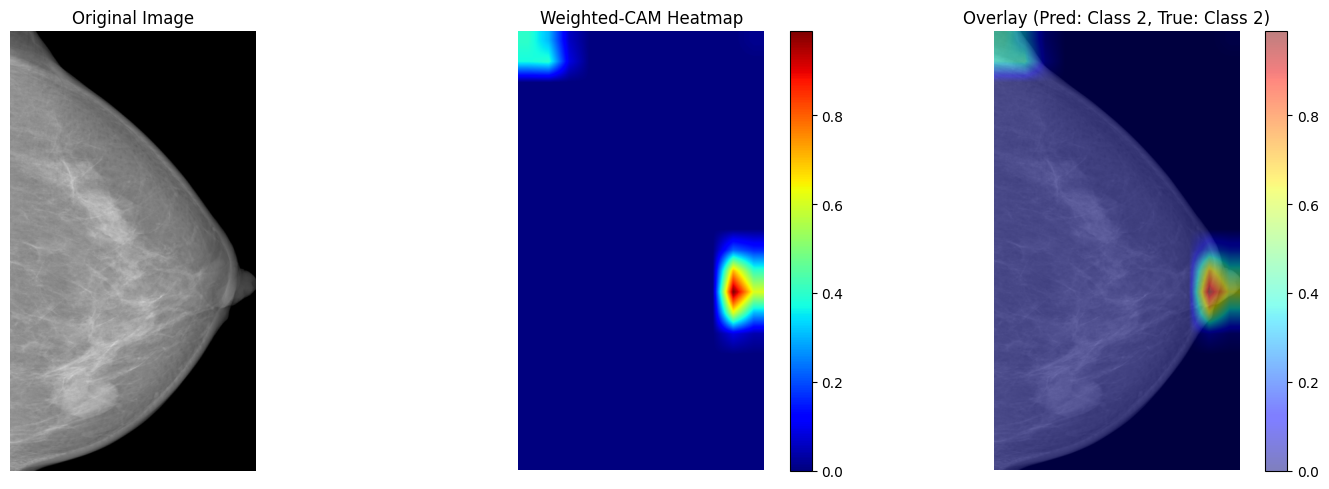

In [26]:
fig = get_weighted_cam_from_dataset(model_cancer, dataloader.test_dataset, annot_row=annot_test.iloc[0], cam_weights=cancer_individual_first_loadings, plot=True)
fig = get_weighted_cam_from_dataset(model_density, dataloader.test_dataset, annot_row=annot_test.iloc[0], cam_weights=dens_individual_first_loadings, plot=True)

# first individual mode of variation focus in cancer vs density network

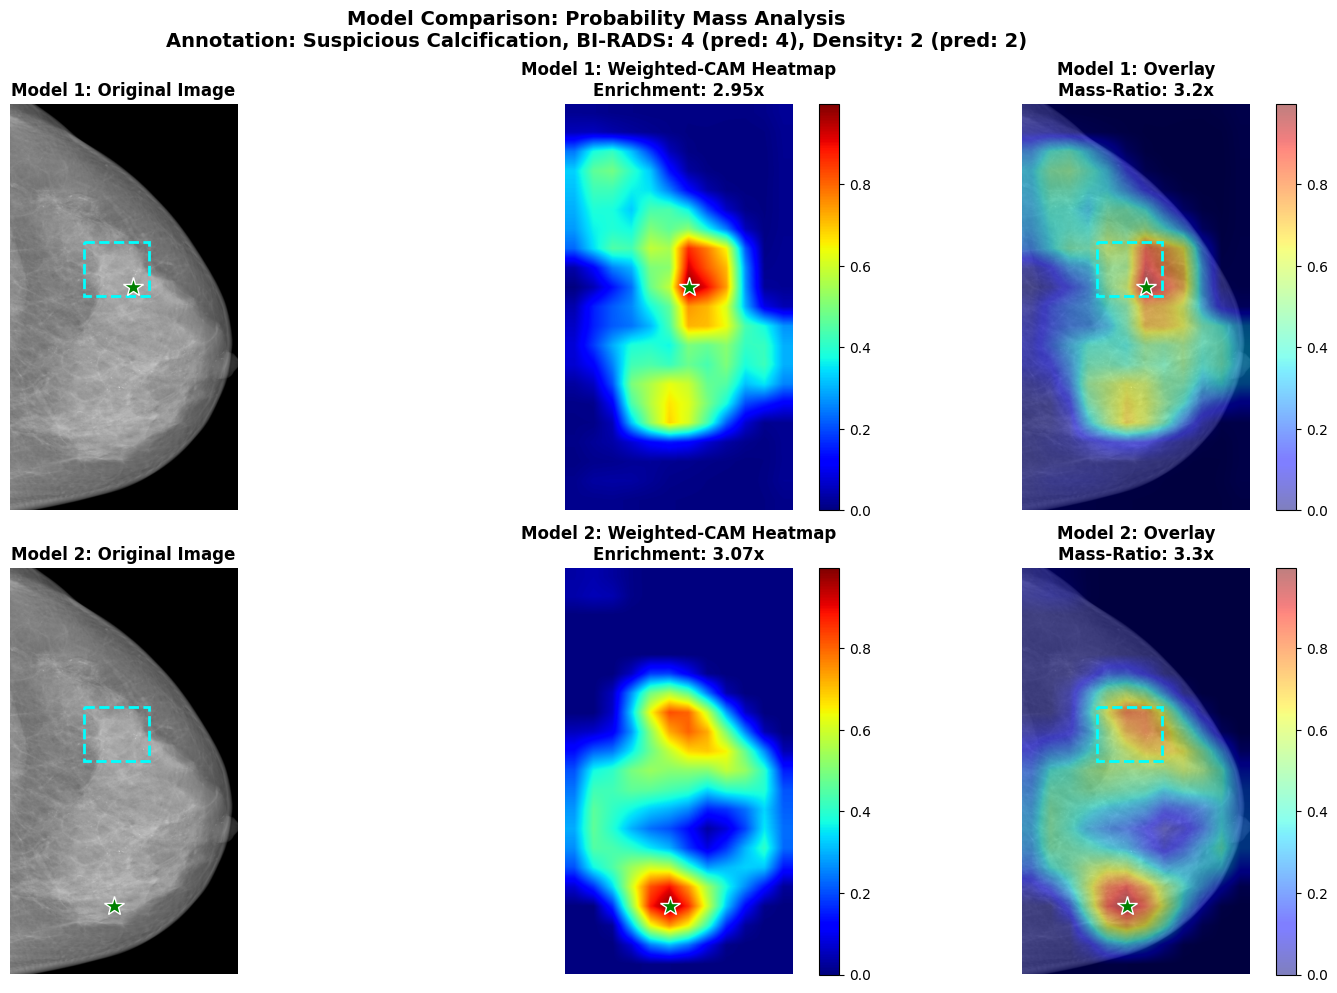

In [27]:
_ = plot_probability_mass_comparison(model_cancer, model_density, dataloader.test_dataset, annot_test.iloc[11], cancer_individual_first_loadings, dens_individual_first_loadings)

In [28]:
results_cancer1indiv = process_all_annotations_ajive(model_cancer, dataloader.test_dataset, annot_test, cancer_individual_first_loadings)

Processing annotations: 100%|██████████| 488/488 [00:30<00:00, 16.04it/s]


In [29]:
results_dens1indiv = process_all_annotations_ajive(model_density, dataloader.test_dataset, annot_test, dens_individual_first_loadings)

Processing annotations: 100%|██████████| 488/488 [00:31<00:00, 15.33it/s]


In [30]:
results_cancer1joint = process_all_annotations_ajive(model_cancer, dataloader.test_dataset, annot_test, cancer_joint_first_loadings)

Processing annotations: 100%|██████████| 488/488 [00:30<00:00, 16.11it/s]

Found 25 annotations with zero-mass saliency in the image. Indices: [32, 175, 186, 270, 271, 272, 273, 327, 328, 357, 358, 359, 384, 398, 400, 401, 402, 403, 404, 414, 418, 466, 467, 468, 469]


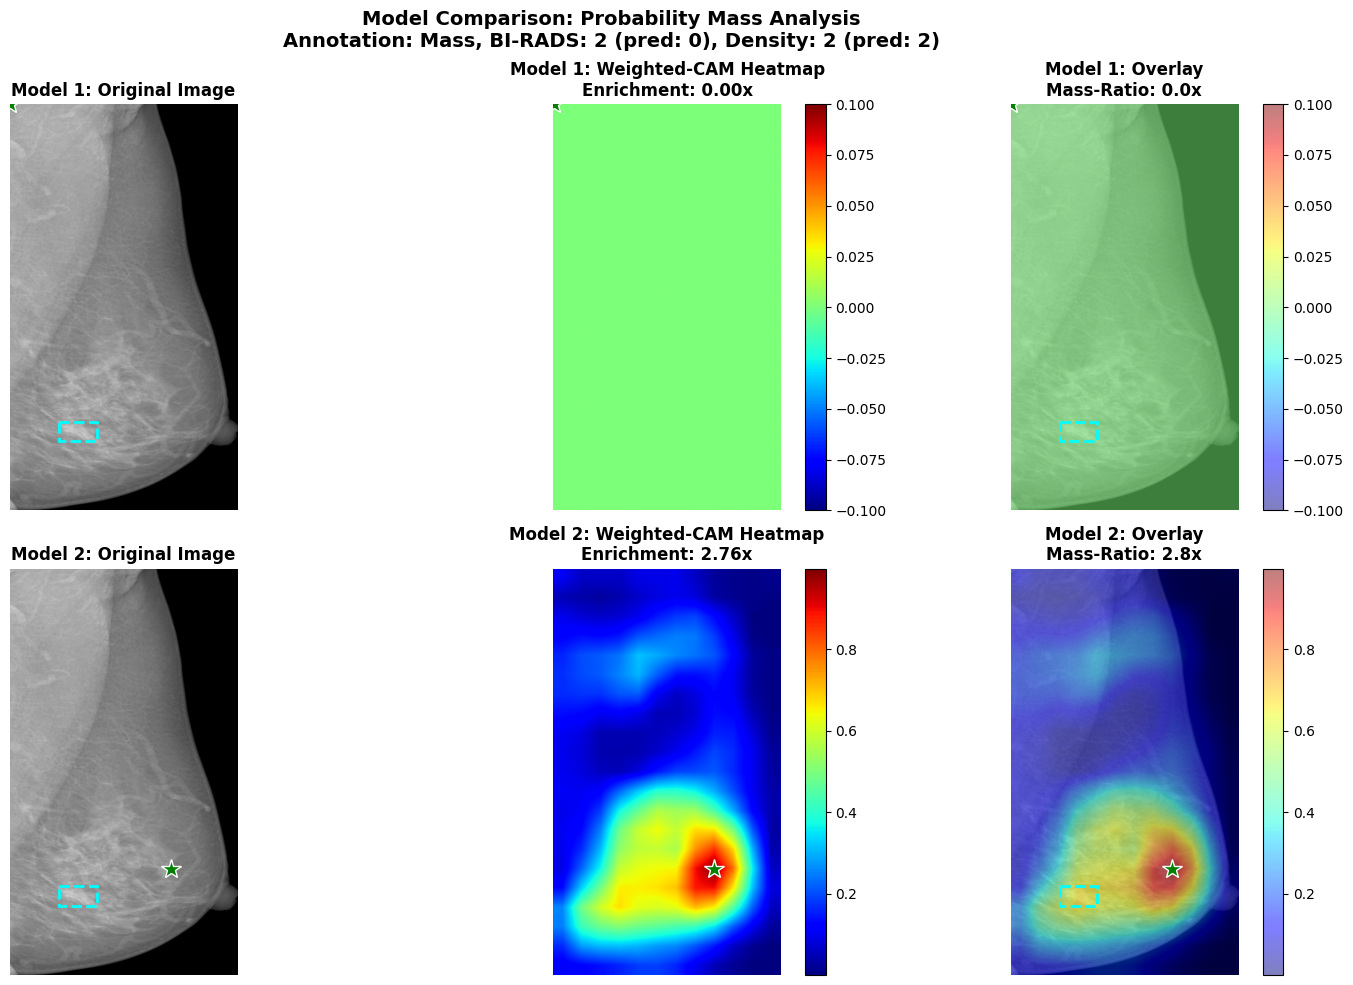

In [50]:
_ = plot_probability_mass_comparison(model_cancer, model_density, dataloader.test_dataset, annot_test.iloc[32], cancer_joint_first_loadings, cancer_individual_first_loadings)

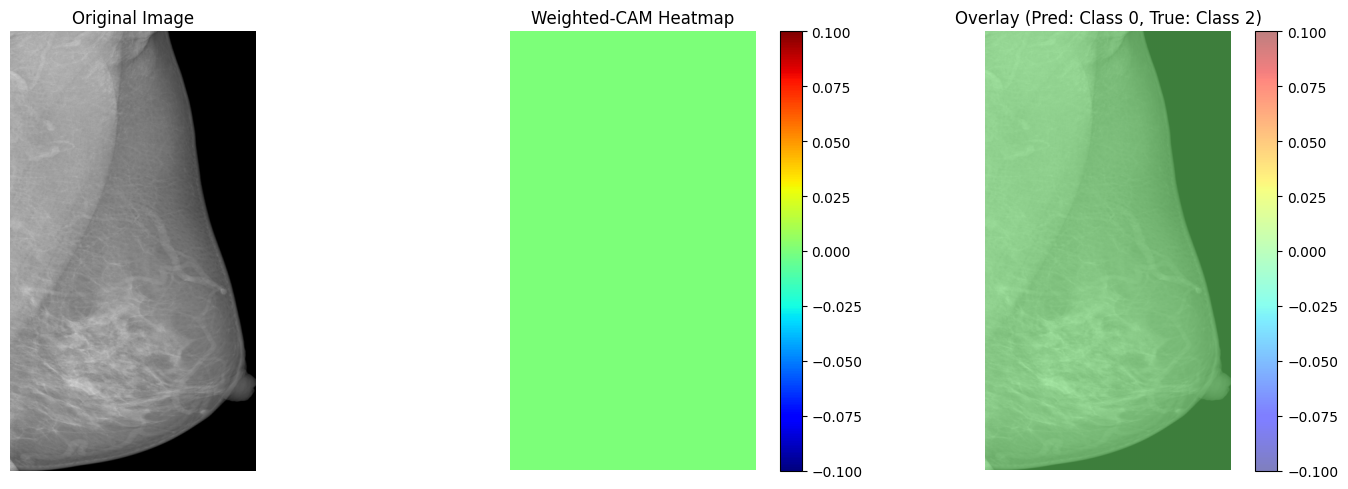

In [51]:
weighted_cam, predicted_class, label1, label2, ajive_score, image_tensor = get_weighted_cam_from_dataset(model_cancer, dataloader.test_dataset, annot_test.iloc[32], cancer_joint_first_loadings, plot=True)

In [52]:
cam, pred, score = model_cancer.generate_weighted_cam(image_tensor.unsqueeze(0), cancer_joint_first_loadings)
score

tensor([-5.5341])

In [53]:
cam_weights = torch.tensor(cancer_joint_first_loadings).unsqueeze(0).unsqueeze(2).unsqueeze(3)
model_cancer.eval()
model_cancer.activations = {}
model_cancer.resnet.layer4[-1].register_forward_hook(model_cancer.get_activation("layer4"))

x = image_tensor.unsqueeze(0).clone().detach().requires_grad_(False)

output= model_cancer(x)

activation = model_cancer.activations["layer4"]  # Shape: (1, 512, H', W')

ga_pooled_activations = activation.mean(dim=[2, 3])  # Shape: (batch_size, num_features)

ajive_score = (ga_pooled_activations * torch.tensor(cancer_joint_first_loadings)).sum(dim=1)  # Shape: (batch_size,)

cam = (cam_weights * activation).sum(dim=1)  # Shape: (batch_size, H', W')

#cam = torch.nn.functional.relu(cam)


In [54]:
cam.mean()

tensor(-5.5341)

In [55]:
ga_pooled_activations.shape
cancer_joint_first_loadings
cam.squeeze().shape


torch.Size([21, 12])

np.True_

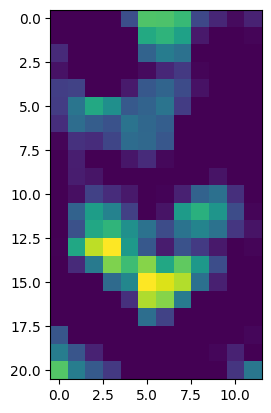

In [56]:
activation.shape
plt.imshow(activation[0,4,:,:].cpu().numpy())
(activation[0,:,:,:].cpu().numpy()>=0).all()

#model_cancer.resnet.layer4[-1].conv2.weight

In [15]:
def plot_localization_metrics(results_list,
                              method_labels=None,
                              stratify=None,
                              correct_only=False,
                              top_k=None,
                              birads_values=None,
                              metrics=("enrichment", "mass_ratio", "pointing_game"),
                              figsize=(20, 6),
                              group_width=0.8,
                              y_limit_quantile=0.95,
                              y_limit_scale=1.15):
    """
    General-purpose visualization for localization metrics across multiple result tables.

    Parameters
    ----------
    results_list : list[pd.DataFrame]
        Each dataframe should include columns:
        ['finding_category', 'BI-RADS', 'predicted_class', 'enrichment', 'mass_ratio', 'pointing_game'].
    method_labels : list[str] | None
        Labels for each result table (used in legend). Defaults to Method 1..N.
    stratify : None | str | list[str] | tuple[str]
        - None: no stratification (single group: "All")
        - "finding_category": group by finding_category
        - "BI-RADS": group by BI-RADS
        - ("finding_category", "BI-RADS"): group by category and BI-RADS
    correct_only : bool
        If True, filter to correctly classified samples based on the FIRST dataframe's predictions
        (BI-RADS == predicted_class). This filter is applied to all dataframes using the same indices.
    top_k : int | None
        If provided and stratifying by finding_category, keep only top_k categories
        by count (based on the first result table after filtering).
    birads_values : list[int] | None
        Explicit BI-RADS order when stratifying by BI-RADS or category+BI-RADS.
    metrics : tuple[str, ...]
        Metrics to plot. Recognized: "enrichment", "mass_ratio", "pointing_game".
    figsize : tuple
        Figure size.
    group_width : float
        Width allocated per group on the x-axis (split across methods).
    y_limit_quantile : float
        Quantile for robust y-axis limits (e.g., 0.95 to reduce outlier impact).
    y_limit_scale : float
        Multiplier applied to the quantile for headroom.
    """
    if not results_list:
        raise ValueError("results_list must contain at least one dataframe")
    if method_labels is None:
        method_labels = [f"Method {i+1}" for i in range(len(results_list))]
    if len(method_labels) != len(results_list):
        raise ValueError("method_labels length must match results_list length")
    
    # Normalize stratify
    if stratify is None:
        stratify_cols = []
    elif isinstance(stratify, (list, tuple)):
        stratify_cols = list(stratify)
    else:
        stratify_cols = [stratify]

    # Prepare dataframes (correct_only filtering)
    dfs = []
    if correct_only:
        # Filter based on the FIRST dataframe's correct predictions
        ref_correct = results_list[0]["BI-RADS"] == results_list[0]["predicted_class"]
        correct_indices = results_list[0][ref_correct].index
        # Apply the same index filter to all dataframes
        for df in results_list:
            dfs.append(df.loc[correct_indices].copy())
    else:
        dfs = [df.copy() for df in results_list]

    # Build group keys based on the first dataframe (ordering reference)
    ref_df = dfs[0]

    # Optionally limit to top_k categories
    if "finding_category" in stratify_cols and top_k is not None:
        top_categories = (
            ref_df["finding_category"].value_counts().head(top_k).index.tolist()
        )
        dfs = [d[d["finding_category"].isin(top_categories)].copy() for d in dfs]
        ref_df = dfs[0]
    else:
        top_categories = None

    # Determine group keys in a stable, interpretable order
    if not stratify_cols:
        group_keys = [tuple()]
    elif stratify_cols == ["finding_category"]:
        category_order = ref_df["finding_category"].value_counts().index.tolist()
        group_keys = [(cat,) for cat in category_order]
    elif stratify_cols == ["BI-RADS"]:
        if birads_values is None:
            birads_values = sorted(ref_df["BI-RADS"].unique().tolist())
        group_keys = [(b,) for b in birads_values]
    elif stratify_cols == ["finding_category", "BI-RADS"]:
        category_order = ref_df["finding_category"].value_counts().index.tolist()
        if birads_values is None:
            birads_values = sorted(ref_df["BI-RADS"].unique().tolist())
        group_keys = [(cat, b) for cat in category_order for b in birads_values]
    else:
        raise ValueError(f"Unsupported stratify: {stratify_cols}")

    # Build group labels
    if not stratify_cols:
        group_labels = ["All"]
    elif stratify_cols == ["finding_category"]:
        group_labels = [f"{cat}\n(n={len(ref_df[ref_df['finding_category']==cat])})"
                        for (cat,) in group_keys]
    elif stratify_cols == ["BI-RADS"]:
        group_labels = [f"BI-{b+1} (n={len(ref_df[ref_df['BI-RADS']==b])})"
                        for (b,) in group_keys]
    else:
        group_labels = [f"{cat}\nBI-{b+1} (n={len(ref_df[(ref_df['finding_category']==cat) & (ref_df['BI-RADS']==b)])})"
                        for (cat, b) in group_keys]

    # Helper to extract group subset
    def _subset(df, key):
        if not stratify_cols:
            return df
        if stratify_cols == ["finding_category"]:
            return df[df["finding_category"] == key[0]]
        if stratify_cols == ["BI-RADS"]:
            return df[df["BI-RADS"] == key[0]]
        # finding_category + BI-RADS
        return df[(df["finding_category"] == key[0]) & (df["BI-RADS"] == key[1])]

    # Prepare plotting
    n_groups = len(group_keys)
    n_methods = len(dfs)
    x = np.arange(n_groups)
    box_width = group_width / max(n_methods, 1)
    offset_start = -group_width / 2 + box_width / 2

    # Colors
    colors = plt.cm.Set2(np.linspace(0, 1, n_methods))
    
    # When stratifying by both category and BI-RADS, create color variations per category
    # Each method keeps its base color, but varies by finding_category
    if stratify_cols == ["finding_category", "BI-RADS"]:
        category_order = ref_df["finding_category"].value_counts().index.tolist()
        n_categories = len(category_order)
        
        # Create color map: (method_idx, group_key) -> color
        # For each method, create variations of its base color for different categories
        color_map = {}
        for j in range(n_methods):
            base_color = colors[j]
            for i, cat in enumerate(category_order):
                # Create a variation of the method's base color for this category
                # Use a wider range (0.3 to 1.0) for more pronounced differences
                blend_factor = 0.3 + 0.7 * (i / max(n_categories - 1, 1))
                # Blend towards white/lighter for visual distinction
                for b in birads_values:
                    varied_color = base_color.copy()
                    varied_color[:3] = base_color[:3] * blend_factor + (1 - blend_factor) * np.array([1, 1, 1])
                    varied_color[3] = 0.75  # Keep alpha consistent
                    color_map[(j, cat, b)] = varied_color
    else:
        color_map = None

    # Figure layout (up to 3 metrics)
    metric_list = list(metrics)
    n_plots = len(metric_list)
    fig, axes = plt.subplots(1, n_plots, figsize=figsize)
    if n_plots == 1:
        axes = [axes]

    for plot_idx, metric in enumerate(metric_list):
        ax = axes[plot_idx]
        if metric in ("enrichment", "mass_ratio"):
            for j, (df, label) in enumerate(zip(dfs, method_labels)):
                data = [
                    _subset(df, key)[metric].values
                    for key in group_keys
                ]
                pos = x + offset_start + j * box_width
                bp = ax.boxplot(
                    data, positions=pos, widths=box_width, patch_artist=True,
                    showmeans=True, meanprops=dict(marker='D', markerfacecolor='red', markersize=4),
                    boxprops=dict(linewidth=0.8), whiskerprops=dict(linewidth=0.8),
                    capprops=dict(linewidth=0.8), medianprops=dict(linewidth=0.8)
                )
                # Apply colors
                for idx, patch in enumerate(bp["boxes"]):
                    if color_map is not None:
                        # Use method-specific color varied by category
                        patch.set_facecolor(color_map[(j,) + group_keys[idx]])
                    else:
                        # Use method-specific color
                        patch.set_facecolor(colors[j])
                        patch.set_alpha(0.75)
            ax.set_ylabel(metric.replace("_", " ").title(), fontsize=10)
            ax.set_xticks(x)
            ax.set_xticklabels(group_labels, rotation=45, ha="right", fontsize=8)
            ax.grid(axis="y", alpha=0.3)
            if metric == "enrichment":
                ax.axhline(y=1.0, color="red", linestyle="--", alpha=0.5)
            if metric == "mass_ratio":
                ax.axhline(y=1.0, color="red", linestyle="--", alpha=0.5)

            # Robust y-limit (reduce outlier dominance)
            all_vals = []
            for df in dfs:
                for key in group_keys:
                    vals = _subset(df, key)[metric].values
                    if len(vals) > 0:
                        all_vals.append(vals)
            if all_vals:
                all_vals = np.concatenate(all_vals)
                all_vals = all_vals[np.isfinite(all_vals)]
                if all_vals.size > 0:
                    y_max = np.quantile(all_vals, y_limit_quantile) * y_limit_scale
                    if y_max > 0:
                        ax.set_ylim(0, y_max)
        elif metric == "pointing_game":
            max_total = 0
            for j, (df, label) in enumerate(zip(dfs, method_labels)):
                successes = []
                failures = []
                totals = []
                for key in group_keys:
                    sub = _subset(df, key)
                    success = sub["pointing_game"].sum()
                    total = len(sub)
                    successes.append(success)
                    failures.append(total - success)
                    totals.append(total)
                    max_total = max(max_total, total)
                pos = x + offset_start + j * box_width
                
                # Apply colors for pointing_game bars
                for idx in range(len(group_keys)):
                    if color_map is not None:
                        bar_color = color_map[(j,) + group_keys[idx]]
                    else:
                        bar_color = colors[j]
                    
                    ax.bar(pos[idx], successes[idx], width=box_width, color=bar_color, 
                           alpha=0.8, edgecolor='black', linewidth=0.5)
                    ax.bar(pos[idx], failures[idx], width=box_width, bottom=successes[idx], 
                           color=bar_color, alpha=0.3, edgecolor='black', linewidth=0.5)

                # Percentage labels above bars
                for i, total in enumerate(totals):
                    if total > 0:
                        pct = successes[i] / total
                        ax.text(pos[i], successes[i] + failures[i] + max_total * 0.02, f"{pct:.0%}",
                                ha="center", va="bottom", fontsize=6, rotation=45)
            ax.set_ylabel('Number of Samples', fontsize=10)
            ax.set_xticks(x)
            ax.set_xticklabels(group_labels, rotation=45, ha="right", fontsize=8)
            ax.grid(axis="y", alpha=0.3)
            if max_total > 0:
                ax.set_ylim(0, max_total * y_limit_scale)
        else:
            raise ValueError(f"Unsupported metric: {metric}")
        ax.set_title(metric.replace("_", " ").title(), fontsize=11, fontweight="bold")

    # Legend (methods only)
    handles = [plt.Line2D([0], [0], color=colors[j], lw=6) for j in range(n_methods)]
    fig.legend(handles, method_labels, loc="upper right", fontsize=9)

    fig.tight_layout()
    return fig, axes

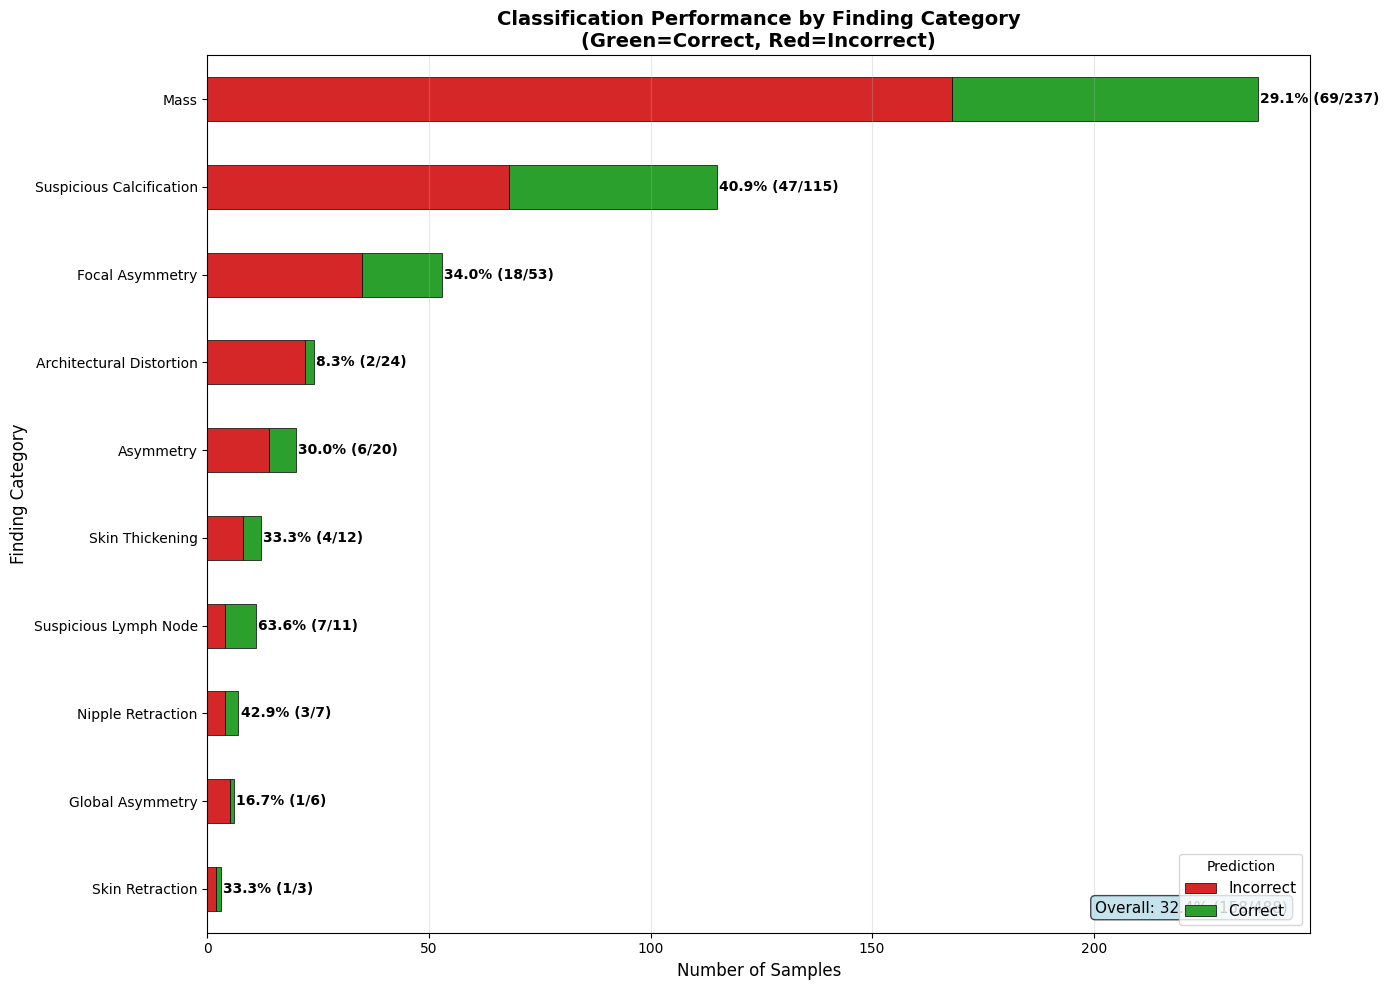

In [58]:
if 1:
    # Visualize classification performance stratified by finding category
    results_cancer1indiv['correct'] = (results_cancer1indiv['BI-RADS'] == results_cancer1indiv['predicted_class']).astype(int)
    accuracy_by_category = results_cancer1indiv.groupby('finding_category').agg({
        'correct': ['mean', 'sum', 'count']
    }).round(3)
    accuracy_by_category.columns = ['Accuracy', 'Correct', 'Total']
    accuracy_by_category = accuracy_by_category.sort_values('Total', ascending=True)

    # Create single comprehensive figure
    fig, ax = plt.subplots(figsize=(14, 10))

    # Stacked bar showing correct/incorrect per category
    category_counts = results_cancer1indiv.groupby(['finding_category', 'correct']).size().unstack(fill_value=0)
    category_counts = category_counts.loc[accuracy_by_category.index]  # Same order as accuracy
    category_counts.plot(kind='barh', stacked=True, ax=ax, color=['#d62728', '#2ca02c'], 
                        edgecolor='black', linewidth=0.5)

    # Add accuracy percentages and ratios as text labels
    for i, (cat, row) in enumerate(accuracy_by_category.iterrows()):
        total = category_counts.loc[cat].sum()
        # Position text at the end of the bar
        ax.text(total + 0.5, i, f"{row['Accuracy']:.1%} ({int(row['Correct'])}/{int(row['Total'])})", 
                va='center', fontsize=10, fontweight='bold')

    ax.set_xlabel('Number of Samples', fontsize=12)
    ax.set_ylabel('Finding Category', fontsize=12)
    ax.set_title('Classification Performance by Finding Category\n(Green=Correct, Red=Incorrect)', 
                fontsize=14, fontweight='bold')
    ax.legend(['Incorrect', 'Correct'], title='Prediction', loc='lower right', fontsize=11)
    ax.grid(axis='x', alpha=0.3)

    # Add overall statistics as text box
    overall_acc = results_cancer1indiv['correct'].mean()
    overall_n = len(results_cancer1indiv)
    overall_correct = results_cancer1indiv['correct'].sum()
    stats_text = f"Overall: {overall_acc:.1%} ({int(overall_correct)}/{overall_n})"
    ax.text(0.98, 0.02, stats_text, transform=ax.transAxes, 
            fontsize=11, verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7, edgecolor='black'))

    plt.tight_layout()
    plt.show()


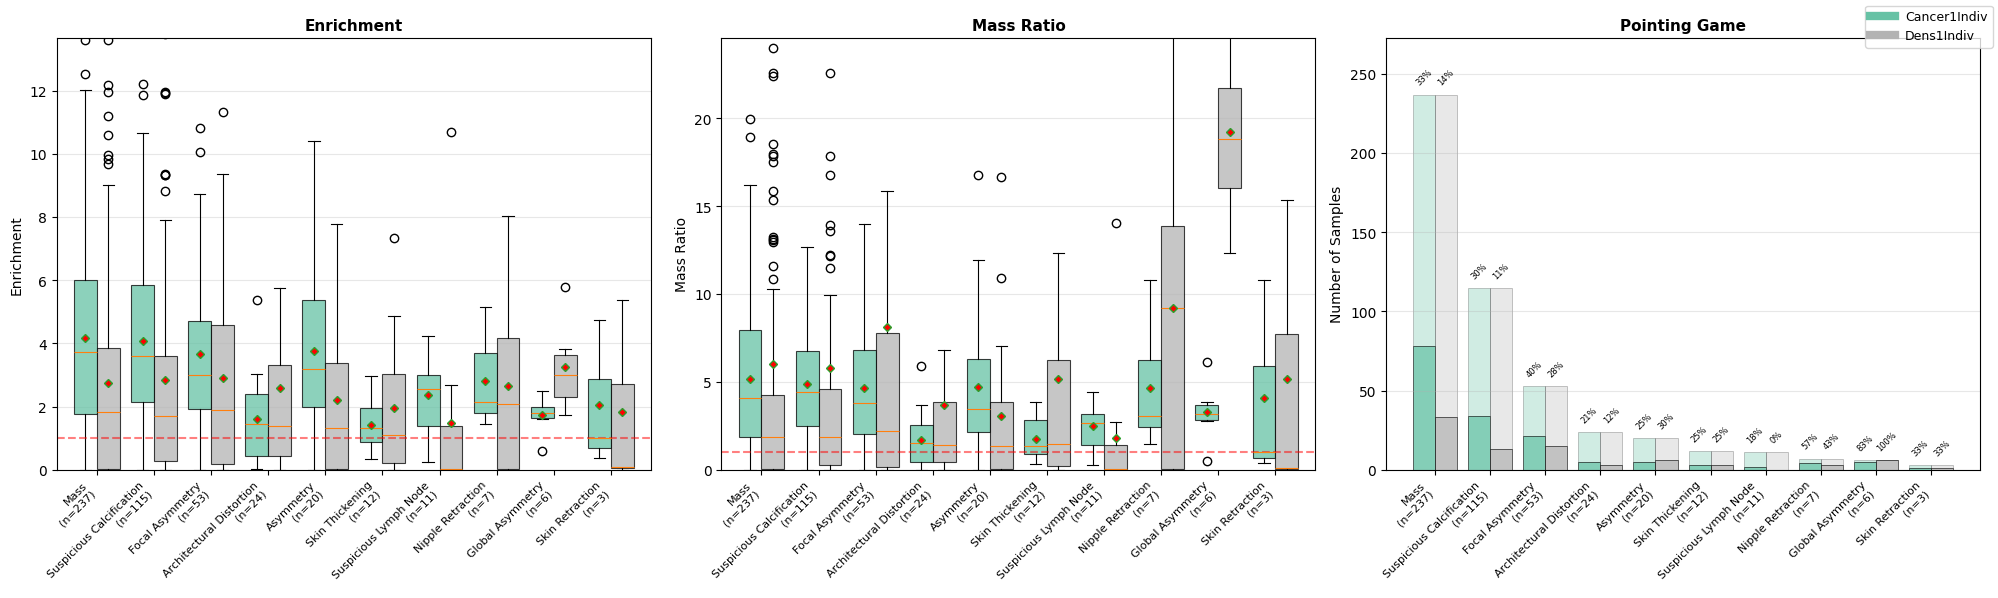

In [59]:
_ = plot_localization_metrics([results_cancer1indiv, results_dens1indiv], method_labels=["Cancer1Indiv","Dens1Indiv"], stratify="finding_category", y_limit_quantile=0.98)

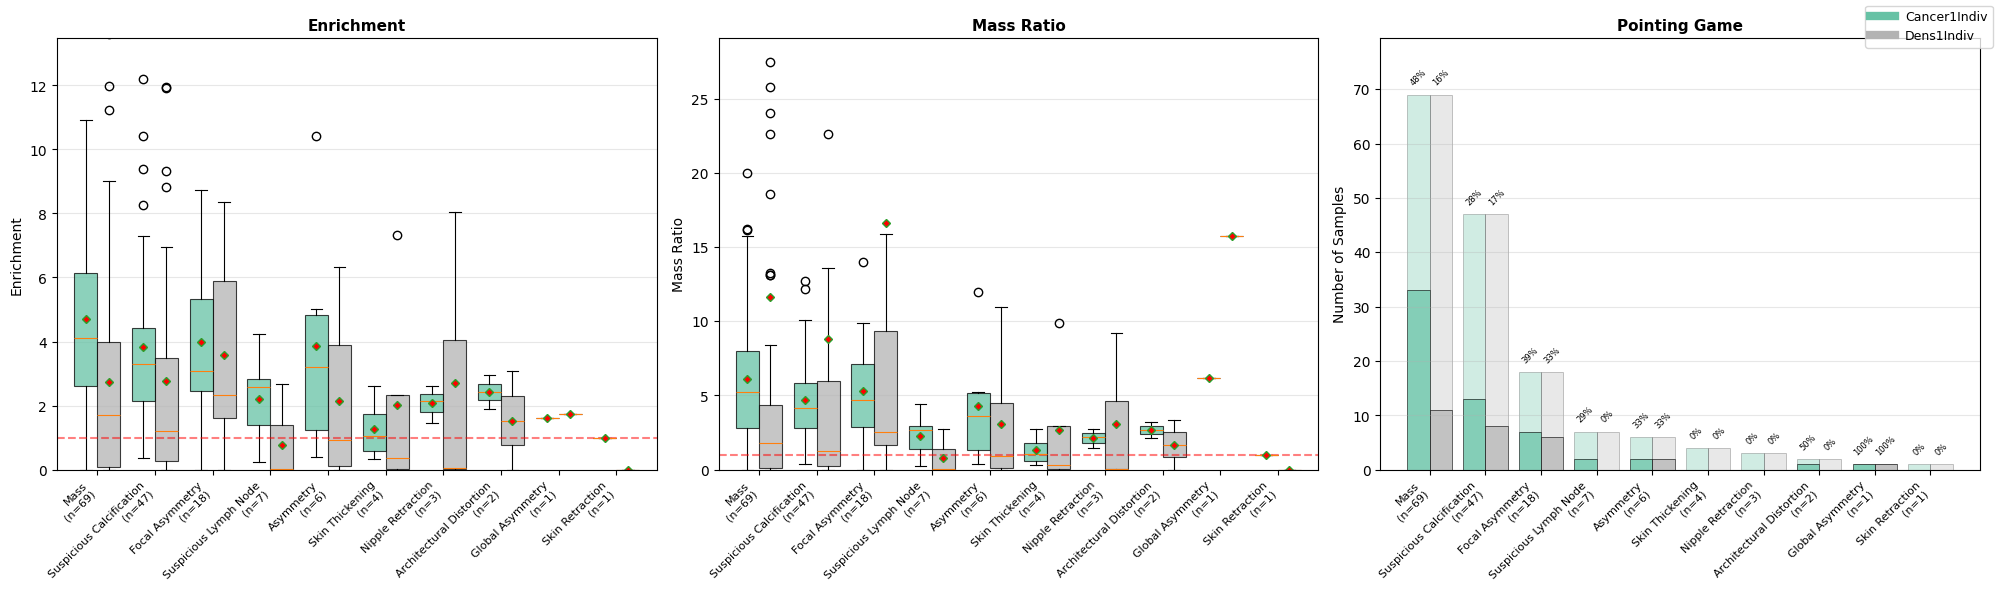

In [60]:
_ = plot_localization_metrics([results_cancer1indiv, results_dens1indiv], method_labels=["Cancer1Indiv","Dens1Indiv"], stratify="finding_category", y_limit_quantile=0.98, correct_only=True)

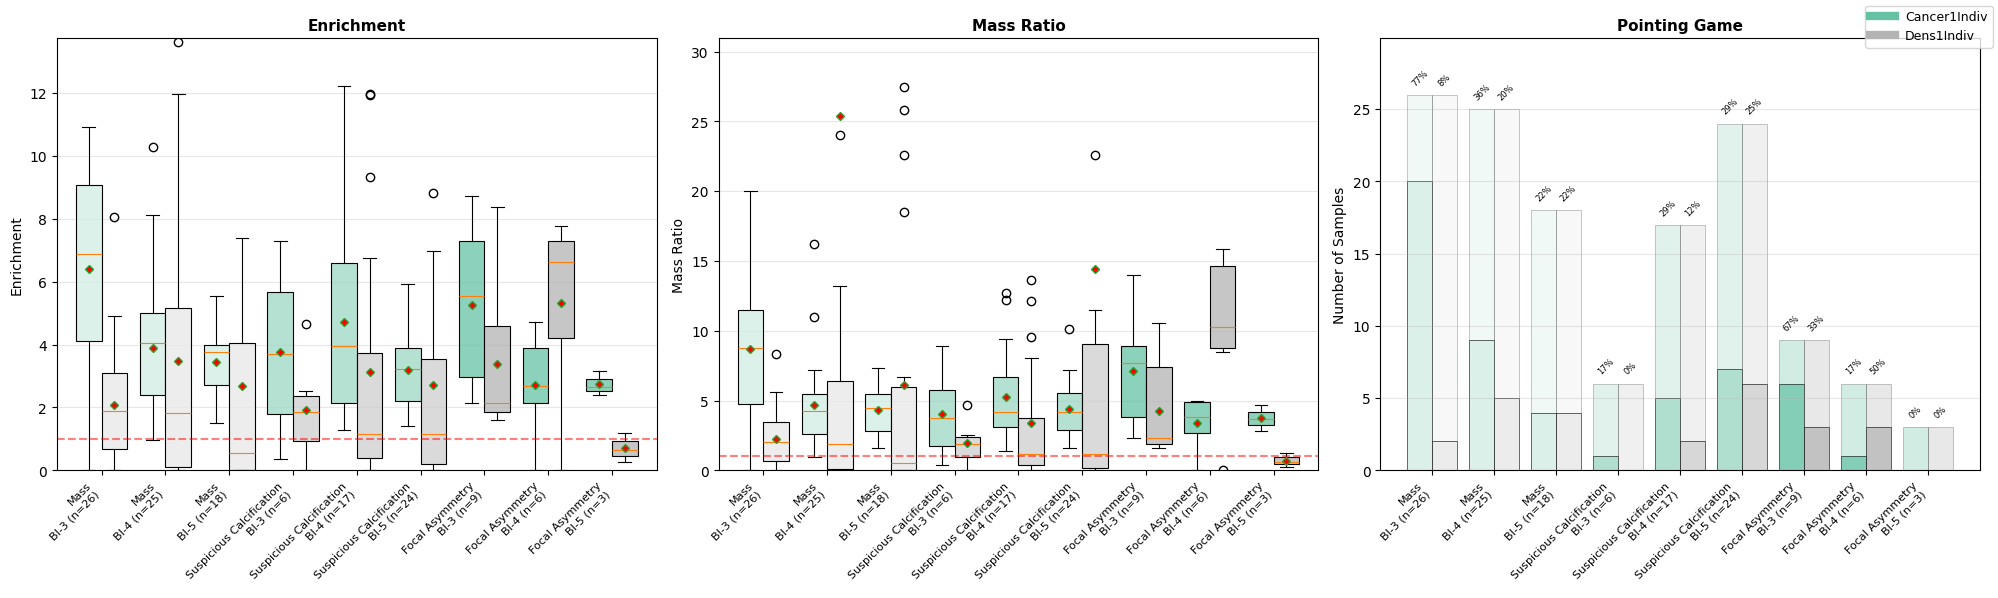

In [61]:
_ = plot_localization_metrics([results_cancer1indiv, results_dens1indiv], method_labels=["Cancer1Indiv","Dens1Indiv"], stratify=["finding_category", "BI-RADS"],top_k=3, y_limit_quantile=0.98, correct_only=True)

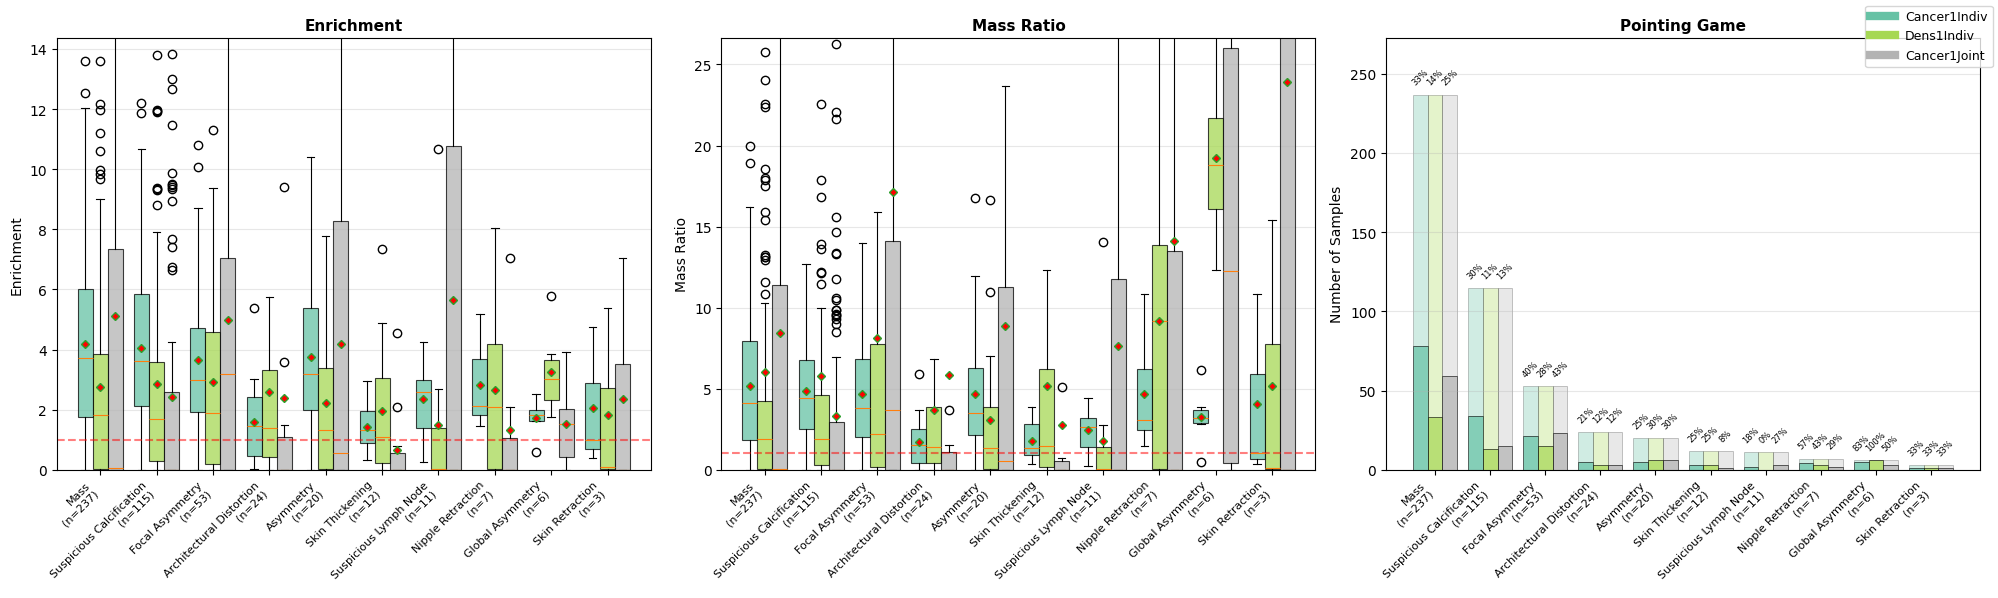

In [62]:
_ = plot_localization_metrics([results_cancer1indiv, results_dens1indiv, results_cancer1joint], method_labels=["Cancer1Indiv","Dens1Indiv","Cancer1Joint"], stratify="finding_category", correct_only=False)

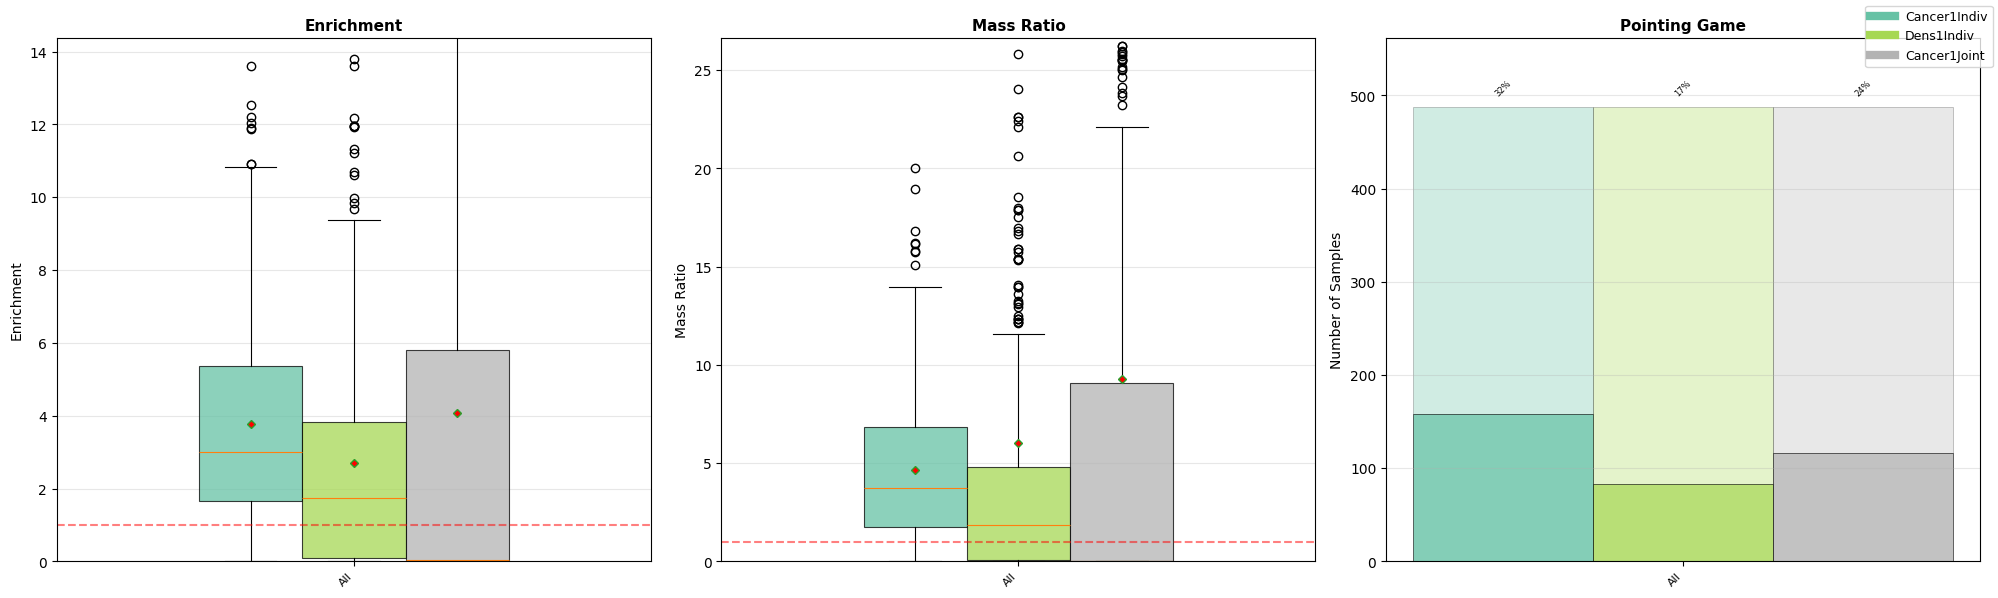

In [63]:
_ = plot_localization_metrics([results_cancer1indiv, results_dens1indiv, results_cancer1joint], method_labels=["Cancer1Indiv","Dens1Indiv","Cancer1Joint"], stratify=None, correct_only=False)

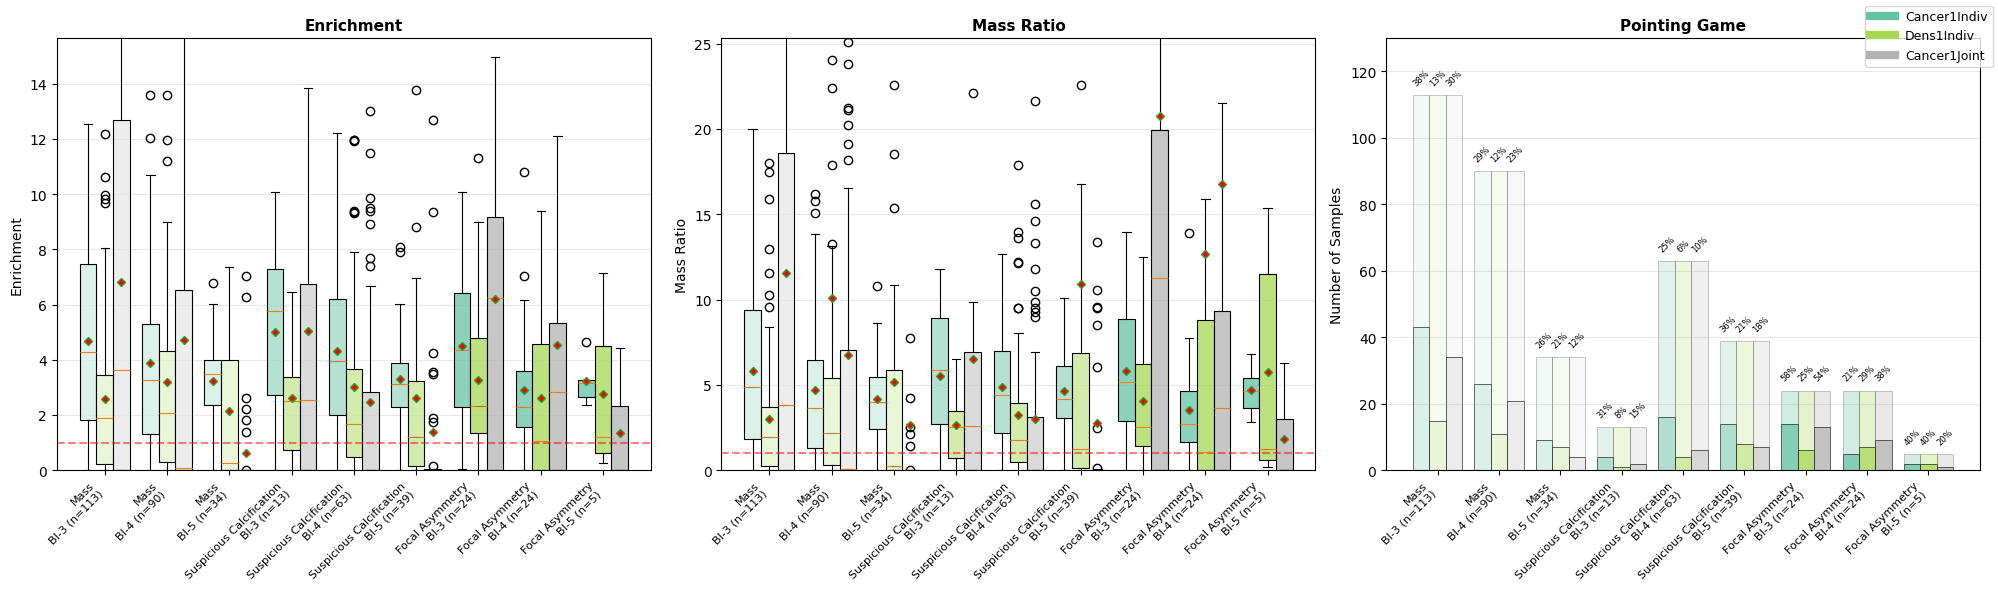

In [64]:
_ = plot_localization_metrics([results_cancer1indiv, results_dens1indiv, results_cancer1joint], method_labels=["Cancer1Indiv","Dens1Indiv","Cancer1Joint"], stratify=["finding_category","BI-RADS"],top_k=3, correct_only=False)

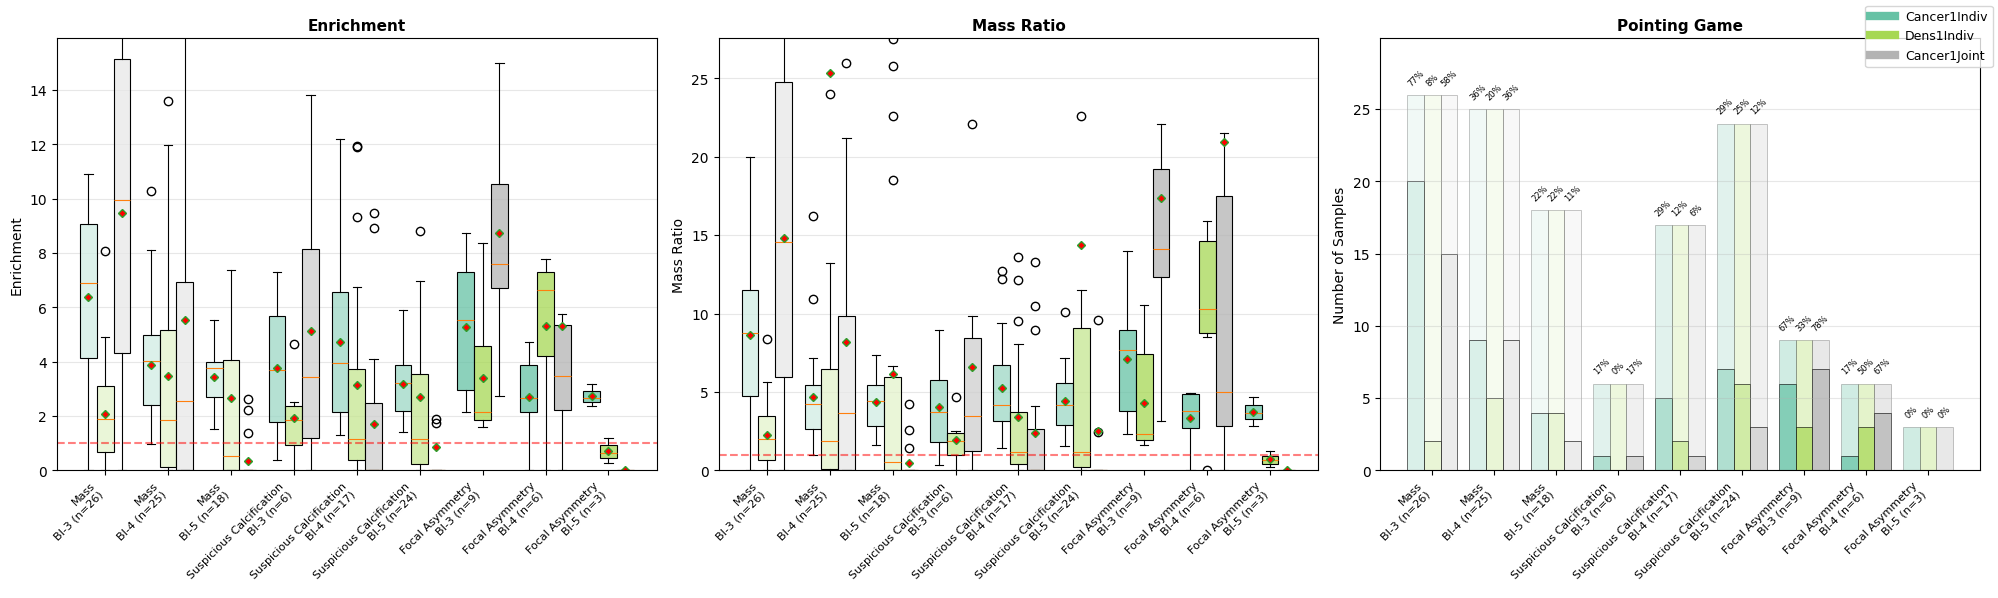

In [65]:
_ = plot_localization_metrics([results_cancer1indiv, results_dens1indiv, results_cancer1joint], method_labels=["Cancer1Indiv","Dens1Indiv","Cancer1Joint"], stratify=["finding_category","BI-RADS"],top_k=3, correct_only=True)

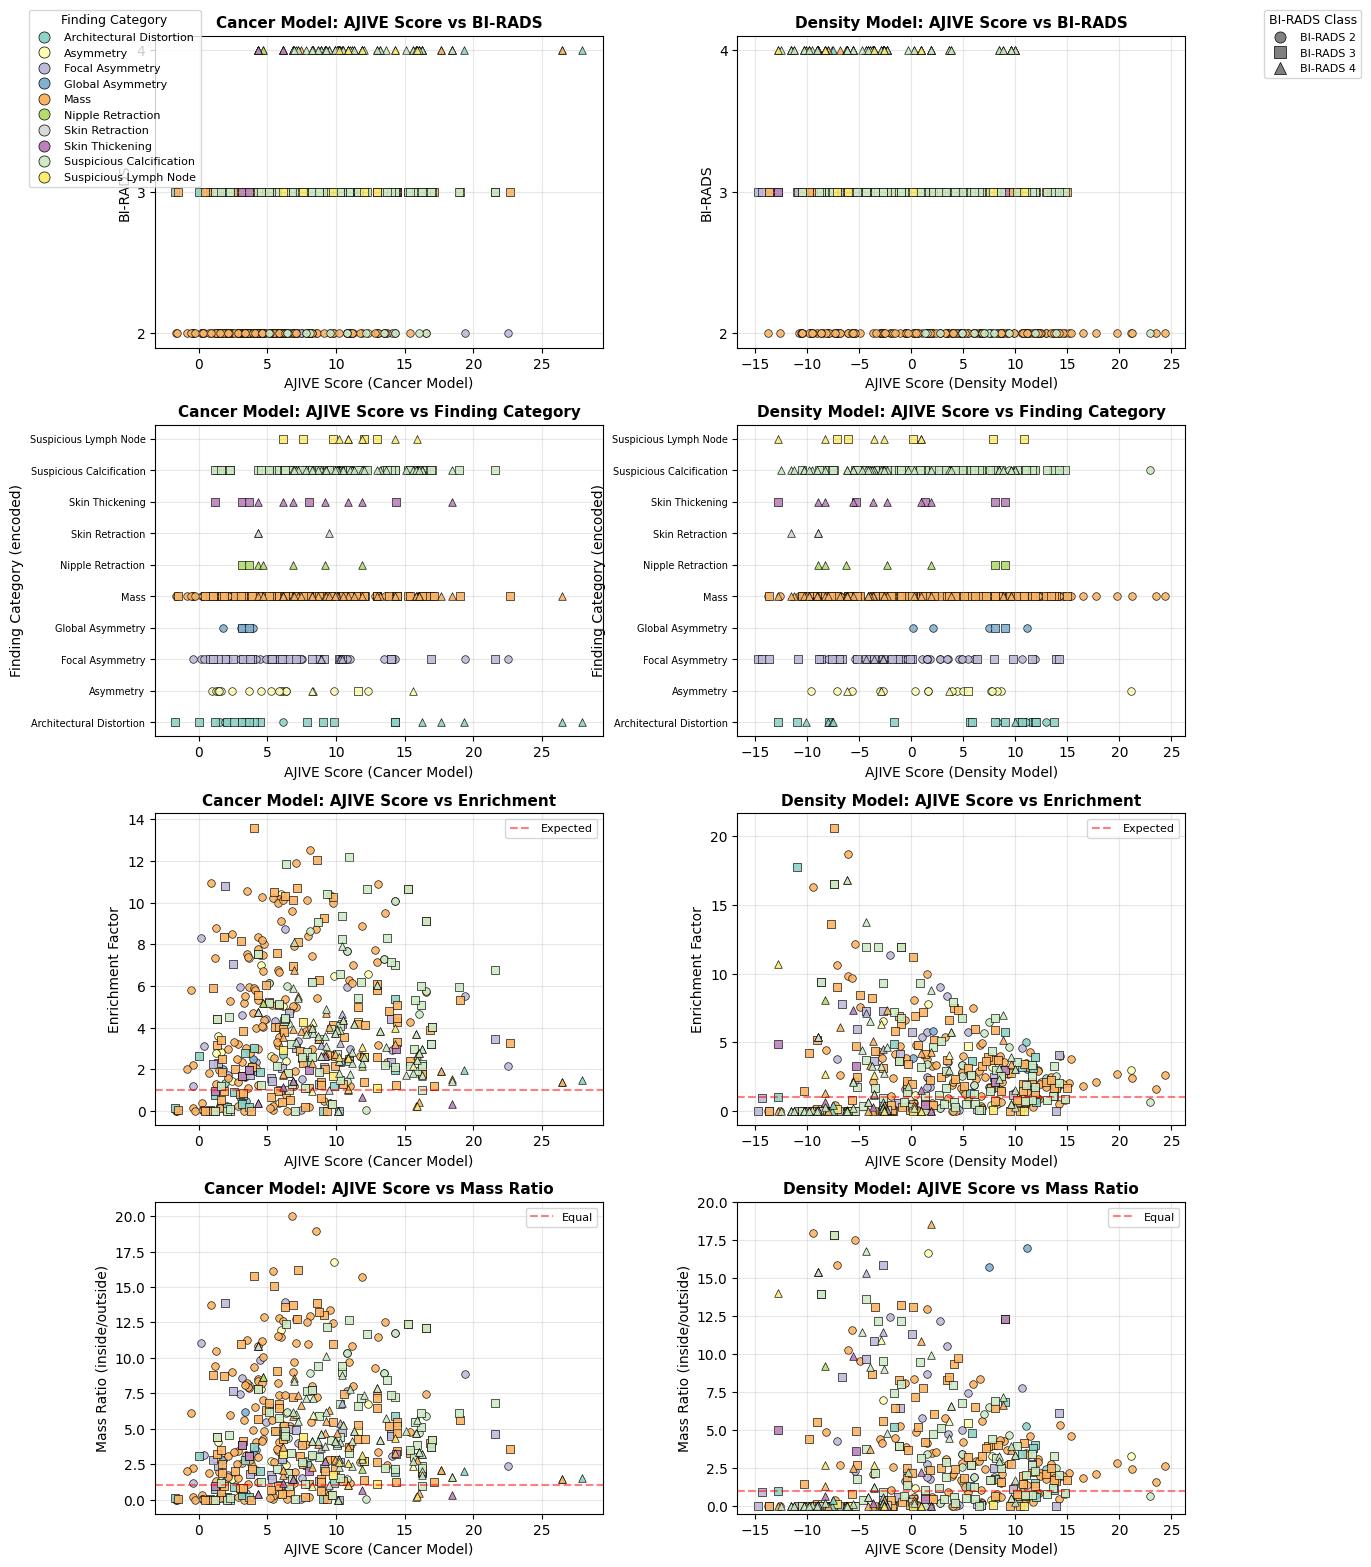

In [66]:
if 1:
    # Create scatterplot matrix showing ajive_score vs various metrics
    # Left column: Cancer model, Right column: Density model
    
    fig, axes = plt.subplots(4, 2, figsize=(14, 16))
    
    # Numerize finding categories for both datasets
    # Create a consistent mapping across both datasets
    all_categories = pd.concat([
        results_cancer1indiv['finding_category'],
        results_dens1indiv['finding_category']
    ]).unique()
    category_to_num = {cat: i for i, cat in enumerate(sorted(all_categories))}
    
    results_cancer1indiv['finding_category_num'] = results_cancer1indiv['finding_category'].map(category_to_num)
    results_dens1indiv['finding_category_num'] = results_dens1indiv['finding_category'].map(category_to_num)
    
    # Create color mapping for finding categories
    unique_categories = sorted(all_categories)
    category_colors = plt.cm.Set3(np.linspace(0, 1, len(unique_categories)))
    category_color_map = {cat: category_colors[i] for i, cat in enumerate(unique_categories)}
    
    # Create marker mapping for BI-RADS classes
    birads_markers = {2: 'o', 3: 's', 4: '^', 5: 'D', 6: 'v'}
    
    # ============== CANCER MODEL (Left Column) ==============
    
    # Row 0: ajive_score vs BI-RADS
    ax = axes[0, 0]
    for birads in sorted(results_cancer1indiv['BI-RADS'].unique()):
        for category in unique_categories:
            mask = (results_cancer1indiv['BI-RADS'] == birads) & (results_cancer1indiv['finding_category'] == category)
            if mask.any():
                ax.scatter(results_cancer1indiv.loc[mask, 'ajive_score'], 
                          results_cancer1indiv.loc[mask, 'BI-RADS'],
                          alpha=0.9, s=30, 
                          c=[category_color_map[category]], 
                          marker=birads_markers.get(birads, 'o'),
                          edgecolors='black', linewidths=0.5,
                          label=f'{category[:15]}... BI-{birads}' if len(mask) > 0 else None)
    ax.set_xlabel('AJIVE Score (Cancer Model)', fontsize=10)
    ax.set_ylabel('BI-RADS', fontsize=10)
    ax.set_title('Cancer Model: AJIVE Score vs BI-RADS', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_yticks(sorted(results_cancer1indiv['BI-RADS'].unique()))
    
    # Row 1: ajive_score vs finding_category (numerized)
    ax = axes[1, 0]
    for birads in sorted(results_cancer1indiv['BI-RADS'].unique()):
        for category in unique_categories:
            mask = (results_cancer1indiv['BI-RADS'] == birads) & (results_cancer1indiv['finding_category'] == category)
            if mask.any():
                ax.scatter(results_cancer1indiv.loc[mask, 'ajive_score'], 
                          results_cancer1indiv.loc[mask, 'finding_category_num'],
                          alpha=0.9, s=30, 
                          c=[category_color_map[category]], 
                          marker=birads_markers.get(birads, 'o'),
                          edgecolors='black', linewidths=0.5)
    ax.set_xlabel('AJIVE Score (Cancer Model)', fontsize=10)
    ax.set_ylabel('Finding Category (encoded)', fontsize=10)
    ax.set_title('Cancer Model: AJIVE Score vs Finding Category', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    # Set y-ticks and labels
    unique_cats = sorted(results_cancer1indiv['finding_category'].unique())
    y_ticks = [category_to_num[cat] for cat in unique_cats]
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(unique_cats, fontsize=7)
    
    # Row 2: ajive_score vs enrichment
    ax = axes[2, 0]
    for birads in sorted(results_cancer1indiv['BI-RADS'].unique()):
        for category in unique_categories:
            mask = (results_cancer1indiv['BI-RADS'] == birads) & (results_cancer1indiv['finding_category'] == category)
            if mask.any():
                ax.scatter(results_cancer1indiv.loc[mask, 'ajive_score'], 
                          results_cancer1indiv.loc[mask, 'enrichment'],
                          alpha=0.9, s=30, 
                          c=[category_color_map[category]], 
                          marker=birads_markers.get(birads, 'o'),
                          edgecolors='black', linewidths=0.5)
    ax.set_xlabel('AJIVE Score (Cancer Model)', fontsize=10)
    ax.set_ylabel('Enrichment Factor', fontsize=10)
    ax.set_title('Cancer Model: AJIVE Score vs Enrichment', fontsize=11, fontweight='bold')
    ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Expected')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    
    # Row 3: ajive_score vs mass_ratio
    ax = axes[3, 0]
    for birads in sorted(results_cancer1indiv['BI-RADS'].unique()):
        for category in unique_categories:
            mask = (results_cancer1indiv['BI-RADS'] == birads) & (results_cancer1indiv['finding_category'] == category)
            if mask.any():
                ax.scatter(results_cancer1indiv.loc[mask, 'ajive_score'], 
                          results_cancer1indiv.loc[mask, 'mass_ratio'],
                          alpha=0.9, s=30, 
                          c=[category_color_map[category]], 
                          marker=birads_markers.get(birads, 'o'),
                          edgecolors='black', linewidths=0.5)
    ax.set_xlabel('AJIVE Score (Cancer Model)', fontsize=10)
    ax.set_ylabel('Mass Ratio (inside/outside)', fontsize=10)
    ax.set_title('Cancer Model: AJIVE Score vs Mass Ratio', fontsize=11, fontweight='bold')
    ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Equal')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    
    # ============== DENSITY MODEL (Right Column) ==============
    
    # Row 0: ajive_score vs BI-RADS
    ax = axes[0, 1]
    for birads in sorted(results_dens1indiv['BI-RADS'].unique()):
        for category in unique_categories:
            mask = (results_dens1indiv['BI-RADS'] == birads) & (results_dens1indiv['finding_category'] == category)
            if mask.any():
                ax.scatter(results_dens1indiv.loc[mask, 'ajive_score'], 
                          results_dens1indiv.loc[mask, 'BI-RADS'],
                          alpha=0.9, s=30, 
                          c=[category_color_map[category]], 
                          marker=birads_markers.get(birads, 'o'),
                          edgecolors='black', linewidths=0.5)
    ax.set_xlabel('AJIVE Score (Density Model)', fontsize=10)
    ax.set_ylabel('BI-RADS', fontsize=10)
    ax.set_title('Density Model: AJIVE Score vs BI-RADS', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_yticks(sorted(results_dens1indiv['BI-RADS'].unique()))
    
    # Row 1: ajive_score vs finding_category (numerized)
    ax = axes[1, 1]
    for birads in sorted(results_dens1indiv['BI-RADS'].unique()):
        for category in unique_categories:
            mask = (results_dens1indiv['BI-RADS'] == birads) & (results_dens1indiv['finding_category'] == category)
            if mask.any():
                ax.scatter(results_dens1indiv.loc[mask, 'ajive_score'], 
                          results_dens1indiv.loc[mask, 'finding_category_num'],
                          alpha=0.9, s=30, 
                          c=[category_color_map[category]], 
                          marker=birads_markers.get(birads, 'o'),
                          edgecolors='black', linewidths=0.5)
    ax.set_xlabel('AJIVE Score (Density Model)', fontsize=10)
    ax.set_ylabel('Finding Category (encoded)', fontsize=10)
    ax.set_title('Density Model: AJIVE Score vs Finding Category', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    # Set y-ticks and labels
    unique_cats = sorted(results_dens1indiv['finding_category'].unique())
    y_ticks = [category_to_num[cat] for cat in unique_cats]
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(unique_cats, fontsize=7)
    
    # Row 2: ajive_score vs enrichment
    ax = axes[2, 1]
    for birads in sorted(results_dens1indiv['BI-RADS'].unique()):
        for category in unique_categories:
            mask = (results_dens1indiv['BI-RADS'] == birads) & (results_dens1indiv['finding_category'] == category)
            if mask.any():
                ax.scatter(results_dens1indiv.loc[mask, 'ajive_score'], 
                          results_dens1indiv.loc[mask, 'enrichment'],
                          alpha=0.9, s=30, 
                          c=[category_color_map[category]], 
                          marker=birads_markers.get(birads, 'o'),
                          edgecolors='black', linewidths=0.5)
    ax.set_xlabel('AJIVE Score (Density Model)', fontsize=10)
    ax.set_ylabel('Enrichment Factor', fontsize=10)
    ax.set_title('Density Model: AJIVE Score vs Enrichment', fontsize=11, fontweight='bold')
    ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Expected')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    
    # Row 3: ajive_score vs mass_ratio
    ax = axes[3, 1]
    for birads in sorted(results_dens1indiv['BI-RADS'].unique()):
        for category in unique_categories:
            mask = (results_dens1indiv['BI-RADS'] == birads) & (results_dens1indiv['finding_category'] == category)
            if mask.any():
                ax.scatter(results_dens1indiv.loc[mask, 'ajive_score'], 
                          results_dens1indiv.loc[mask, 'mass_ratio'],
                          alpha=0.9, s=30, 
                          c=[category_color_map[category]], 
                          marker=birads_markers.get(birads, 'o'),
                          edgecolors='black', linewidths=0.5)
    ax.set_xlabel('AJIVE Score (Density Model)', fontsize=10)
    ax.set_ylabel('Mass Ratio (inside/outside)', fontsize=10)
    ax.set_ylim(-0.5, 20)
    ax.set_title('Density Model: AJIVE Score vs Mass Ratio', fontsize=11, fontweight='bold')
    ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Equal')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    
    # Create custom legends
    # Category legend (colors)
    category_handles = [plt.Line2D([0], [0], marker='o', color='w', 
                                   markerfacecolor=category_color_map[cat], 
                                   markersize=8, label=cat, markeredgecolor='black', markeredgewidth=0.5)
                       for cat in unique_categories]
    
    # BI-RADS legend (markers)
    birads_handles = [plt.Line2D([0], [0], marker=birads_markers.get(birads, 'o'), color='w', 
                                 markerfacecolor='gray', markersize=8, 
                                 label=f'BI-RADS {birads}', markeredgecolor='black', markeredgewidth=0.5)
                     for birads in sorted(set(list(results_cancer1indiv['BI-RADS'].unique()) + 
                                             list(results_dens1indiv['BI-RADS'].unique())))]
    
    # Add legends outside the plot area
    fig.legend(handles=category_handles, loc='upper left', bbox_to_anchor=(0.02, 0.98), 
               title='Finding Category', fontsize=8, title_fontsize=9, ncol=1)
    fig.legend(handles=birads_handles, loc='upper right', bbox_to_anchor=(0.98, 0.98), 
               title='BI-RADS Class', fontsize=8, title_fontsize=9, ncol=1)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.96, right=0.85)
    plt.show()

# ____________________________________________________________________________________________________________________________________________
# ____________________________________________________________________________________________________________________________________________
# ____________________________________________________________________________________________________________________________________________
# ____________________________________________________________________________________________________________________________________________
# ____________________________________________________________________________________________________________________________________________
# Using Single_view_AJIVE_heads module

# Using `Single_view_AJIVE_heads`

Train an AJIVE head on the frozen ResNet features, then inspect the fitted head with test metrics and Grad-CAM visualizations.

## Training AJIVE Heads for All Models

In [49]:

def load_ajive_head_checkpoint(path: str, backbone, map_location: str = "cpu"):
    """Load AJIVE-head checkpoint safely on CPU/MPS even if it was trained on CUDA."""
    ckpt = torch.load(path, map_location=map_location, weights_only=False)
    hp = ckpt["hyper_parameters"]
    
    view_index = backbone.task - 1

    model = Single_view_AJIVE_heads.load_from_checkpoint(
        path,
        map_location=map_location,
        model=backbone,
        ajive_model=hp["ajive_model"],
        num_class=hp["num_class"],
        learning_rate=hp.get("learning_rate", 1e-3),
        hidden_dim=hp.get("hidden_dim", 56),
        drop=hp.get("drop", 0.3),
        active_head=hp.get("active_head", "both"),
        view_index=view_index,
    )
    return model

cancer_ajive_model = load_ajive_head_checkpoint("artifacts/model-vh6h5rl3:v0/model.ckpt", model_cancer)
density_ajive_model = load_ajive_head_checkpoint("artifacts/model-2cd4kra5:v0/model.ckpt", model_density)

# Determine device
device = 'mps' if torch.backends.mps.is_available() else 'cpu'

# Put models in eval mode and move to device
model_cancer = model_cancer.to(device).eval()
model_density = model_density.to(device).eval()
cancer_ajive_model = cancer_ajive_model.to(device).eval()
density_ajive_model = density_ajive_model.to(device).eval()

/Users/jazav7774/UiT/FYS-8603/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/parsing.py:209: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


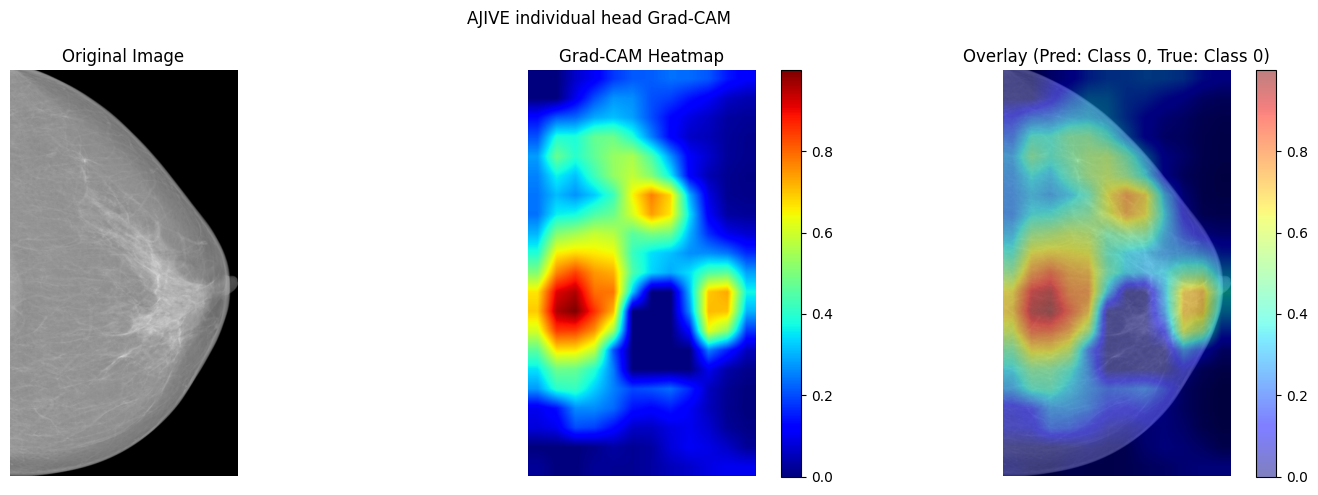

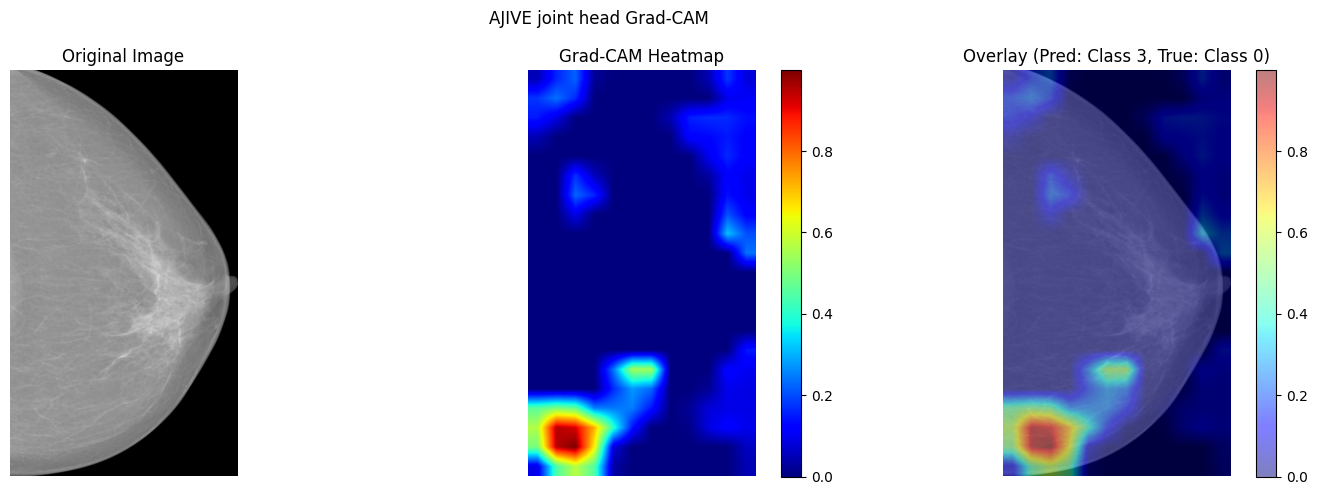

In [53]:
test_batch = next(iter(dataloader.test_dataloader()))
images, cancer_labels, density_labels = test_batch
sample_idx = 0

cancer_ajive_model.set_active_head("individual")
fig = visualize_grad_cam(
    cancer_ajive_model,
    images[sample_idx].to("mps"),
    image_label=int(cancer_labels[sample_idx]),
    suptitle="AJIVE individual head Grad-CAM",
)
plt.show()

cancer_ajive_model.set_active_head("joint")
fig = visualize_grad_cam(
    cancer_ajive_model,
    images[sample_idx].to("mps"),
    image_label=int(cancer_labels[sample_idx]),
    suptitle="AJIVE joint head Grad-CAM",
)
plt.show()

## Classification Accuracy Comparison

In [55]:
if 1:
    # Get test data
    test_dataloader = dataloader.test_dataloader()
    all_predictions = {
        'original_cancer': [],
        'original_density': [],
        'cancer_joint': [],
        'cancer_individual': [],
        'cancer_both': [],
        'density_joint': [],
        'density_individual': [],
        'density_both': [],
    }
    all_labels_cancer = []
    all_labels_density = []

    head_names = cancer_ajive_model.heads.keys()  # Assuming both models have the same head names

    print("\n" + "="*80)
    print(f"EVALUATING ALL MODELS ON TEST SET (Device: {device.upper()})")
    print("="*80)

    import time
    eval_start = time.time()

    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm.tqdm(test_dataloader, desc="Evaluating batches")):
            images, cancer_labels, density_labels = batch
            
            # Move to device
            images = images.to(device)
            
            # Original models predictions
            cancer_pred = model_cancer(images).argmax(dim=1).cpu().numpy()
            density_pred = model_density(images).argmax(dim=1).cpu().numpy()

            all_predictions['original_cancer'].extend(cancer_pred)
            all_predictions['original_density'].extend(density_pred)

            # Cancer AJIVE heads predictions
            for head_name in head_names:
                cancer_ajive_model.set_active_head(head_name)
                head_pred = cancer_ajive_model(images, head_name=head_name).argmax(dim=1).cpu().numpy()
                all_predictions[f'cancer_{head_name}'].extend(head_pred)

            # Density AJIVE heads predictions
            for head_name in head_names:
                density_ajive_model.set_active_head(head_name)
                head_pred = density_ajive_model(images, head_name=head_name).argmax(dim=1).cpu().numpy()
                all_predictions[f'density_{head_name}'].extend(head_pred)

            all_labels_cancer.extend(cancer_labels.cpu().numpy())
            all_labels_density.extend(density_labels.cpu().numpy())

    eval_elapsed = time.time() - eval_start
    print(f"✓ Evaluation complete in {eval_elapsed:.1f}s")

    # Convert to numpy arrays
    all_labels_cancer = np.array(all_labels_cancer)
    all_labels_density = np.array(all_labels_density)

    # Compute metrics
    results = []

    # Cancer models
    cancer_models = ['original_cancer', 'cancer_joint', 'cancer_individual', 'cancer_both']
    for model_name in cancer_models:
        preds = np.array(all_predictions[model_name])
        acc = accuracy_score(all_labels_cancer, preds)
        f1 = f1_score(all_labels_cancer, preds, average='macro', zero_division=0)
        results.append({
            'Model': model_name.replace('_', ' ').title(),
            'Task': 'Cancer',
            'Accuracy': acc,
            'F1-Score': f1
        })

    # Density models
    density_models = ['original_density', 'density_joint', 'density_individual', 'density_both']
    for model_name in density_models:
        preds = np.array(all_predictions[model_name])
        acc = accuracy_score(all_labels_density, preds)
        f1 = f1_score(all_labels_density, preds, average='macro', zero_division=0)
        results.append({
            'Model': model_name.replace('_', ' ').title(),
            'Task': 'Density',
            'Accuracy': acc,
            'F1-Score': f1
        })

    # Create results dataframe
    results_df = pd.DataFrame(results)
    print("\n" + "="*80)
    print("CLASSIFICATION ACCURACY COMPARISON")
    print("="*80)
    print(results_df.to_string(index=False))
    print("="*80)


EVALUATING ALL MODELS ON TEST SET (Device: MPS)


Evaluating batches: 100%|██████████| 125/125 [07:57<00:00,  3.82s/it]

✓ Evaluation complete in 477.5s

CLASSIFICATION ACCURACY COMPARISON
             Model    Task  Accuracy  F1-Score
   Original Cancer  Cancer   0.71850  0.468564
      Cancer Joint  Cancer   0.59850  0.285466
 Cancer Individual  Cancer   0.69000  0.462139
       Cancer Both  Cancer   0.67875  0.464121
  Original Density Density   0.76150  0.541391
     Density Joint Density   0.84950  0.564236
Density Individual Density   0.85050  0.560584
      Density Both Density   0.84625  0.561365


In [56]:
preds = np.array(all_predictions['original_density'])
sum(preds == all_labels_density)

np.int64(3046)

In [57]:
# AJIVE-head Grad-CAM localization analysis on all test annotations
device_eval = "mps" if torch.backends.mps.is_available() else "cpu"

def _get_gradcam_saliency_ajive_head(model, dataset, annot_row, head_name, use_true_class=False):
    """
    Generate Grad-CAM saliency map for one annotation using an AJIVE head.
    
    Args:
        model: AJIVE head model
        dataset: Dataset with image_ids
        annot_row: Annotation row with image_id
        head_name: Name of AJIVE head (joint, individual, both)
        use_true_class: If True, compute Grad-CAM for true class. If False, use predicted class.
    
    Returns:
        saliency_map, predicted_class, true_label_y1, true_label_y2
    """
    dataloader_idx = np.where(dataset.image_ids == annot_row["image_id"])[0][0]
    image_tensor, label1, label2 = dataset[dataloader_idx]
    y1_label = int(label1.item() if torch.is_tensor(label1) else label1)
    y2_label = int(label2.item() if torch.is_tensor(label2) else label2)
    
    model = model.to(device_eval).eval()
    
    # Determine target class for Grad-CAM
    true_label = y1_label if model.task == 1 else y2_label
    target_class = true_label if use_true_class else None  # None will default to predicted class in generate_grad_cam
    
    # Generate Grad-CAM
    cam, predicted_class = model.generate_grad_cam(
        image_tensor.unsqueeze(0).to(device_eval),
        target_class=target_class,
        head_name=head_name,
    )
    
    saliency_map = cam.squeeze(0).numpy()
    
    return saliency_map, predicted_class.item(), y1_label, y2_label

def process_all_annotations_gradcam_ajive_head(model, dataset, annot_df, head_name, model_name, use_true_class=False):
    """
    Compute localization metrics for all annotations using AJIVE-head Grad-CAM.
    
    Args:
        model: AJIVE head model
        dataset: Dataset with image_ids
        annot_df: DataFrame with annotations
        head_name: AJIVE head name (joint, individual, both)
        model_name: Name identifier for this model
        use_true_class: If True, compute Grad-CAM for true class; if False, for predicted class
    
    Returns:
        DataFrame with all annotations and localization metrics
    """
    results = []
    problematic_indices = []
    
    desc = f"{model_name}-{head_name} (true_class={use_true_class})"
    
    for idx, row in tqdm.tqdm(annot_df.iterrows(), total=len(annot_df), desc=desc):
        saliency_map, pred_class, y1_label, y2_label = _get_gradcam_saliency_ajive_head(
            model, dataset, row, head_name, use_true_class=use_true_class
        )
        
        if saliency_map.sum() == 0:
            problematic_indices.append(idx)
        
        bbox_mask, enrichment, mean_inside, mean_outside, mass_ratio, pointing_game = calculate_bbox_probability_mass(
            saliency_map, row
        )
        
        # Determine correctness: check if predicted == true for the relevant task
        correct = (pred_class == y1_label) if model.task == 1 else (pred_class == y2_label)
        
        results.append({
            "model_name": model_name,
            "head_name": head_name,
            "patient_id": row["patient_id"],
            "series_id": row["series_id"],
            "image_id": row["image_id"],
            "view": row["view"],
            "laterality": row["laterality"],
            "finding_category": row["finding_category"],
            "BI-RADS": y1_label,
            "Density": y2_label,
            "predicted_class": pred_class,
            "correct": correct,
            "enrichment": enrichment,
            "mean_inside": mean_inside,
            "mean_outside": mean_outside,
            "mass_ratio": mass_ratio,
            "pointing_game": bool(pointing_game),
            "bbox_mask": bbox_mask,
        })
    
    results_df = pd.DataFrame(results)
    if problematic_indices:
        print(f"{desc}: {len(problematic_indices)} zero-mass saliency maps.")
    return results_df

# Run evaluation for all AJIVE heads on all test annotations
test_loader = dataloader.test_dataloader()
dataset = dataloader.test_dataset

ajive_models = {
    "cancer_ajive": cancer_ajive_model,
    "density_ajive": density_ajive_model,
}

ajive_head_results_pred = []
ajive_head_results_true = []

print("=" * 80)
print("Processing AJIVE-head Grad-CAM on all test annotations")
print("=" * 80)

for model_name, ajive_model in ajive_models.items():
    for head_name in ajive_model.head_names:
        # Compute Grad-CAM with respect to predicted class (default)
        df_pred = process_all_annotations_gradcam_ajive_head(
            ajive_model, dataset, annot_test.copy(), 
            head_name=head_name, 
            model_name=model_name,
            use_true_class=False
        )
        ajive_head_results_pred.append(df_pred)
        
        # Compute Grad-CAM with respect to true class
        df_true = process_all_annotations_gradcam_ajive_head(
            ajive_model, dataset, annot_test.copy(), 
            head_name=head_name, 
            model_name=model_name,
            use_true_class=True
        )
        ajive_head_results_true.append(df_true)
        
        n_correct_pred = df_pred["correct"].sum()
        n_correct_true = df_true["correct"].sum()
        print(f"  {head_name}: {n_correct_pred} correct (Grad-CAM pred), {n_correct_true} correct (Grad-CAM true)")

print("\n" + "=" * 80)
print("Created object for analysis:")
print("- ajive_head_results_pred: list of DataFrames (predicted class)")
print("- ajive_head_results_true: list of DataFrames (true class)")
print("  Each DataFrame has columns: ['correct', 'enrichment', 'mass_ratio', 'pointing_game', 'model_name', 'head_name', ...]")
print("  Use .filter() or list comprehension to select only correctly classified samples.")
print("  Directly compatible with plot_localization_metrics(ajive_head_results_list, method_labels=[...])")
print("=" * 80)


Processing AJIVE-head Grad-CAM on all test annotations


cancer_ajive-joint (true_class=True):  42%|████▏     | 207/488 [00:08<00:12, 22.54it/s]

cancer_ajive-joint (true_class=True):  87%|████████▋ | 426/488 [00:19<00:03, 20.13it/s]

cancer_ajive-joint (true_class=True):  98%|█████████▊| 480/488 [00:22<00:00, 19.22it/s]

cancer_ajive-joint (true_class=True): 100%|██████████| 488/488 [00:22<00:00, 21.39it/s]


...

  joint: 430 correct (Grad-CAM pred), 430 correct (Grad-CAM true)


density_ajive-individual (true_class=True): 100%|██████████| 488/488 [00:38<00:00, 12.66it/s]


  individual: 435 correct (Grad-CAM pred), 435 correct (Grad-CAM true)


density_ajive-both (true_class=True): 100%|██████████| 488/488 [00:39<00:00, 12.36it/s]

  both: 419 correct (Grad-CAM pred), 419 correct (Grad-CAM true)

Created object for analysis:
- ajive_head_results_pred: list of DataFrames (predicted class)
- ajive_head_results_true: list of DataFrames (true class)
  Each DataFrame has columns: ['correct', 'enrichment', 'mass_ratio', 'pointing_game', 'model_name', 'head_name', ...]
  Use .filter() or list comprehension to select only correctly classified samples.
  Directly compatible with plot_localization_metrics(ajive_head_results_list, method_labels=[...])


In [26]:
print(f"Number of DataFrames in list: {len(ajive_head_results_true)}")
print("\nDataFrame sizes (rows per head-mode combination):")
for i, df in enumerate(ajive_head_results_true):
    model = df["model_name"].iloc[0] if len(df) > 0 else "unknown"
    head = df["head_name"].iloc[0] if len(df) > 0 else "unknown"
    n_correct = df["correct"].sum() if len(df) > 0 else 0
    print(f"  [{i}] {model}-{head}: {len(df)} samples, {n_correct} correct")


Number of DataFrames in list: 6

DataFrame sizes (rows per head-mode combination):
  [0] cancer_ajive-joint: 488 samples, 72 correct
  [1] cancer_ajive-individual: 488 samples, 65 correct
  [2] cancer_ajive-both: 488 samples, 66 correct
  [3] density_ajive-joint: 488 samples, 430 correct
  [4] density_ajive-individual: 488 samples, 435 correct
  [5] density_ajive-both: 488 samples, 419 correct


2

In [31]:
ajive_head_results_pred[0]

,model_name,head_name,patient_id,series_id,image_id,view,laterality,finding_category,BI-RADS,Density,predicted_class,correct,enrichment,mean_inside,mean_outside,mass_ratio,pointing_game,bbox_mask
0,cancer_ajive,joint,5683854eafabc34f6d854000d2ac6c2d,4ac33111294b83d43537cb8604b0808c,2f944efb1cb9579442df2d7fe6a579b7,CC,L,Mass,2,2,2,True,6.537029,0.025941,0.003248,7.987005,True,"[[False, False, False, False, False, False, Fa..."
1,cancer_ajive,joint,5683854eafabc34f6d854000d2ac6c2d,4ac33111294b83d43537cb8604b0808c,7385e8cf7b29764525c81de4aa1aebe4,MLO,L,Mass,2,2,4,False,6.498736,0.025789,0.003436,7.505315,False,"[[False, False, False, False, False, False, Fa..."
2,cancer_ajive,joint,917a4de3b1f921f1c9fa98b7a61d749d,22bada39b619f79a660b3a06eb6ff5a9,4dd8faf113a9421e03a6e2bcd4238da2,CC,L,Mass,2,2,0,False,1.325548,0.005260,0.003881,1.355465,False,"[[False, False, False, False, False, False, Fa..."
3,cancer_ajive,joint,917a4de3b1f921f1c9fa98b7a61d749d,22bada39b619f79a660b3a06eb6ff5a9,19056b152c5d2ed98f66de006fa45a6c,MLO,L,Mass,2,2,0,False,1.469444,0.005831,0.003938,1.480654,False,"[[False, False, False, False, False, False, Fa..."
4,cancer_ajive,joint,31fa226bc9f87e0a2cb2de6dddbc2270,98ca3b2d3a802a417d2942bc5f0fc036,625aa350502a7038cfe5f9ca5f1a65f4,MLO,L,Mass,3,2,0,False,0.663773,0.002634,0.003984,0.661095,False,"[[False, False, False, False, False, False, Fa..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
483,cancer_ajive,joint,b8acac150be7f949f78dc631a3851f8b,f351166fe105bea6f090e38f41bc844c,dbe631b24f8759c7f7022513582c39ba,CC,R,Mass,3,2,3,False,0.000000,0.000000,0.004000,0.000000,False,"[[False, False, False, False, False, False, Fa..."
484,cancer_ajive,joint,b8acac150be7f949f78dc631a3851f8b,f351166fe105bea6f090e38f41bc844c,bdf1539e07e60cfcb5e7833f5b63fa86,MLO,R,Suspicious Lymph Node,3,2,3,False,0.000000,0.000000,0.003984,0.000000,False,"[[False, False, False, False, False, False, Fa..."
485,cancer_ajive,joint,b8acac150be7f949f78dc631a3851f8b,f351166fe105bea6f090e38f41bc844c,bdf1539e07e60cfcb5e7833f5b63fa86,MLO,R,Mass,3,2,3,False,2.452242,0.009731,0.003875,2.511059,False,"[[False, False, False, False, False, False, Fa..."
486,cancer_ajive,joint,b8acac150be7f949f78dc631a3851f8b,f351166fe105bea6f090e38f41bc844c,bdf1539e07e60cfcb5e7833f5b63fa86,MLO,R,Mass,3,2,3,False,5.491620,0.021792,0.003308,6.587491,False,"[[False, False, False, False, False, False, Fa..."


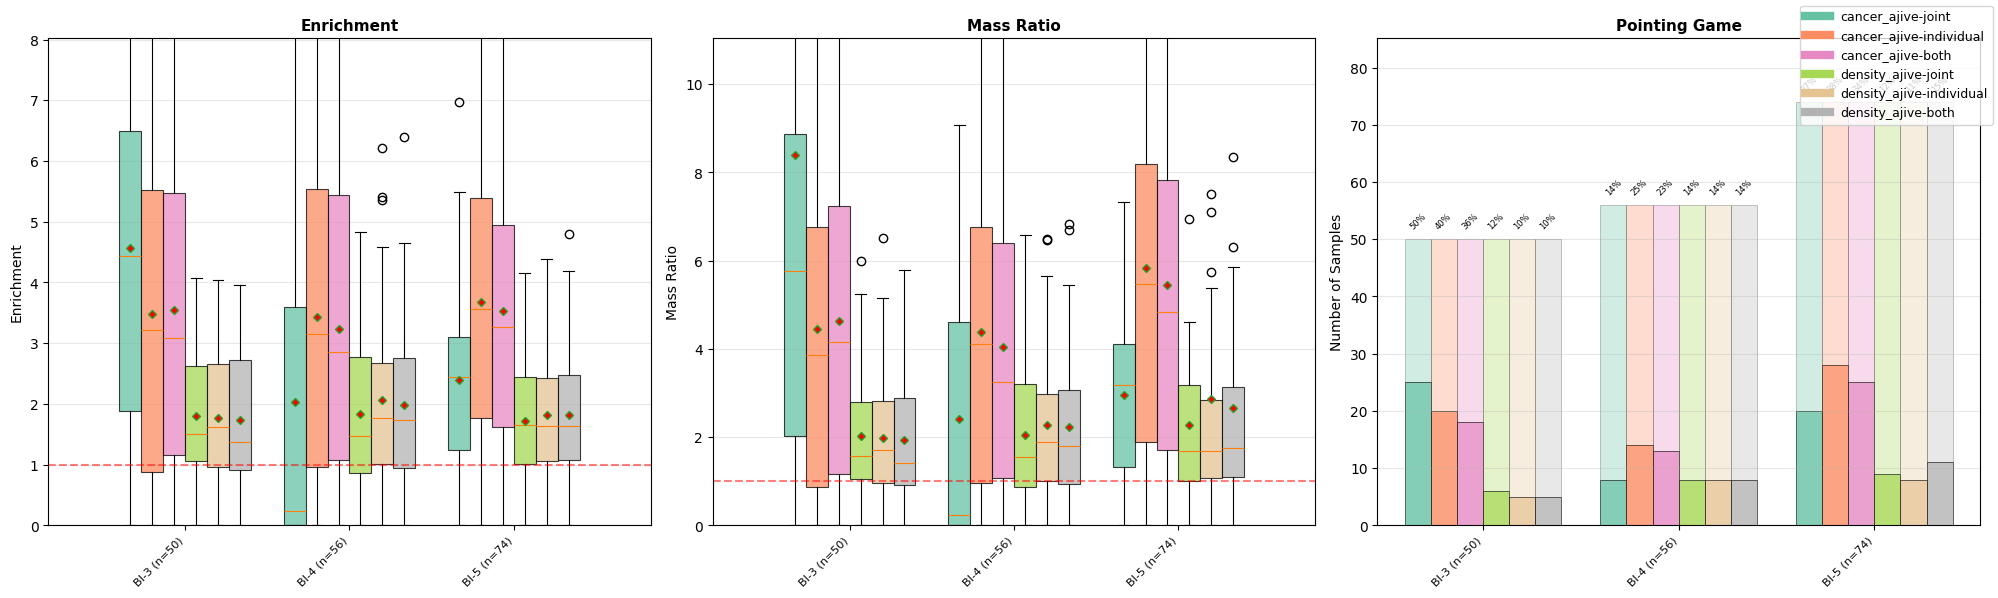

In [24]:
_ = plot_localization_metrics(ajive_head_results_pred, method_labels=[f"{df['model_name'].iloc[0]}-{df['head_name'].iloc[0]}" for df in ajive_head_results_pred], stratify=['BI-RADS'], correct_only=True)


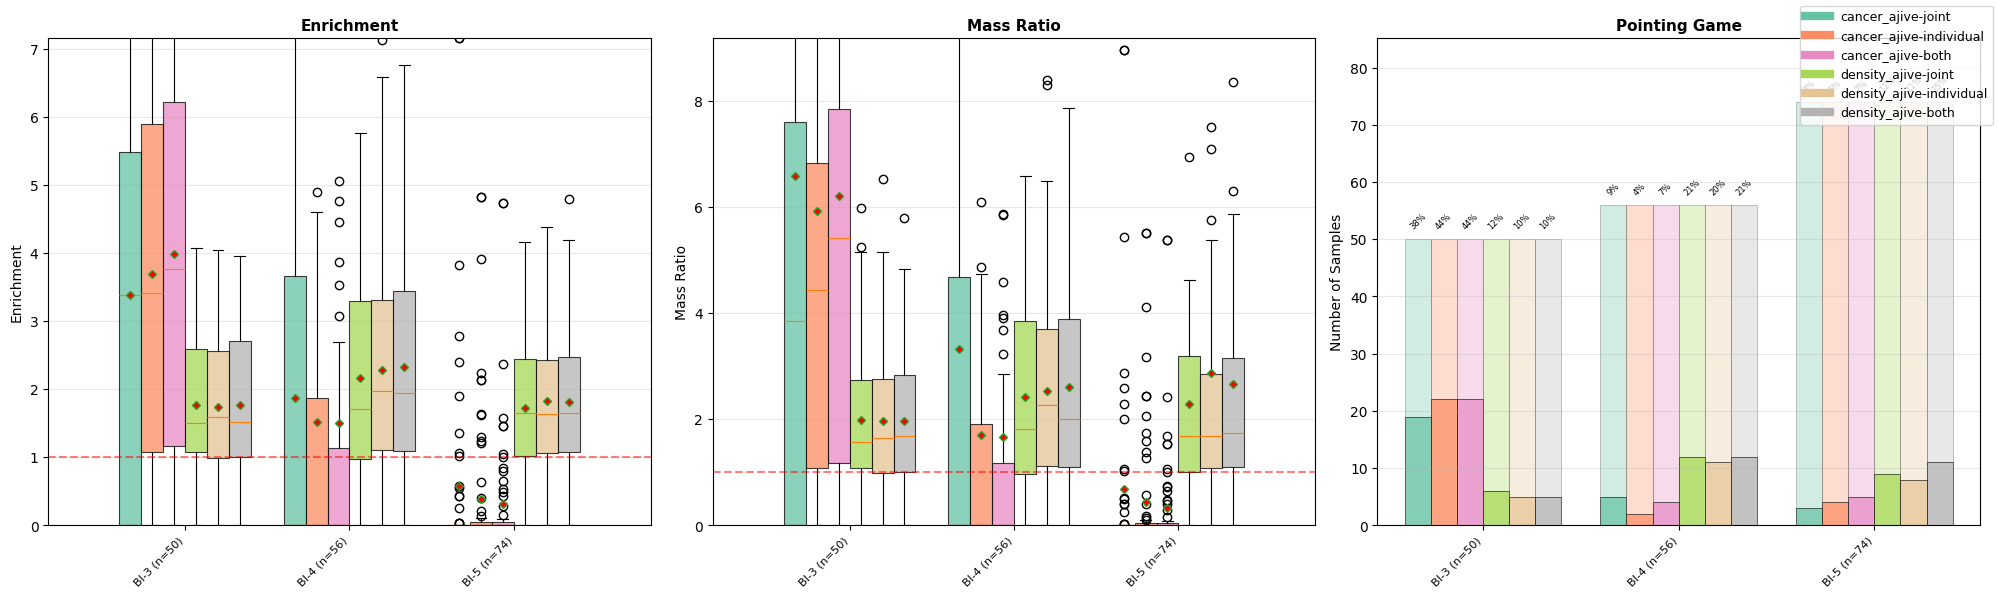

In [25]:
_ = plot_localization_metrics(ajive_head_results_true, method_labels=[f"{df['model_name'].iloc[0]}-{df['head_name'].iloc[0]}" for df in ajive_head_results_true], stratify=['BI-RADS'], correct_only=True)
